# Data Analysis ~ 500

In [1]:
import pandas as pd
import numpy  as np

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

## X1.0 ~ Single | Baseline

passage_time: 10; interval: 3; window: 3

In [4]:
x10_folder_path = '../infra/reports/seq-single_500'

### Predict

In [112]:
from pandas import json_normalize
import json

with open(f'{x10_folder_path}/metrics.json') as f:
    x10_data = json.load(f)

load_model_duration = datetime.fromisoformat(x10_data['load_model_final']) - datetime.fromisoformat(x10_data['load_model_start'])
    
rows = []
for animal, v1 in x10_data['animals'].items():
    row_base = {
        'pid': x10_data['pid'],
        'load_model_start': datetime.fromisoformat(x10_data['load_model_start']),
        'load_model_final': datetime.fromisoformat(x10_data['load_model_final']),
        'load_model_dur': load_model_duration,
        'animal':animal,
        'first_image_capture_time':datetime.fromisoformat(v1['first_image_capture_time']),
        'last_image_capture_time' :datetime.fromisoformat(v1['last_image_capture_time']),
        'display_time' :datetime.fromisoformat(v1['weight_prediction_final']),
        'total_of_images': v1['total_of_images'],
        'suitable_images': v1['suitable_images'],
    }
    
    for img, v2 in v1['imgs'].items():
        row = row_base.copy()
        for k, v3 in v2.items():
            row[k] = datetime.fromisoformat(v3)

        rows.append(row)

dx10_metrics_v0 = pd.DataFrame.from_dict(rows)
dx10_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final
0,single_2026-05-27T14:07:59.206356,2026-05-27 14:07:59.207039,2026-05-27 14:08:06.224033,0 days 00:00:07.016994,1,2026-05-27 14:08:06.224153,2026-05-27 14:08:15.253886,2026-05-27 14:08:16.279934,8,2,2026-05-27 14:08:07.436420,2026-05-27 14:08:08.305470
1,single_2026-05-27T14:07:59.206356,2026-05-27 14:07:59.207039,2026-05-27 14:08:06.224033,0 days 00:00:07.016994,1,2026-05-27 14:08:06.224153,2026-05-27 14:08:15.253886,2026-05-27 14:08:16.279934,8,2,2026-05-27 14:08:09.311240,2026-05-27 14:08:10.181263
2,single_2026-05-27T14:07:59.206356,2026-05-27 14:07:59.207039,2026-05-27 14:08:06.224033,0 days 00:00:07.016994,2,2026-05-27 14:08:19.280048,2026-05-27 14:08:29.175068,2026-05-27 14:08:30.186360,9,2,2026-05-27 14:08:20.291583,2026-05-27 14:08:21.179755
3,single_2026-05-27T14:07:59.206356,2026-05-27 14:07:59.207039,2026-05-27 14:08:06.224033,0 days 00:00:07.016994,2,2026-05-27 14:08:19.280048,2026-05-27 14:08:29.175068,2026-05-27 14:08:30.186360,9,2,2026-05-27 14:08:22.192869,2026-05-27 14:08:23.064948
4,single_2026-05-27T14:07:59.206356,2026-05-27 14:07:59.207039,2026-05-27 14:08:06.224033,0 days 00:00:07.016994,3,2026-05-27 14:08:33.188449,2026-05-27 14:08:43.139201,2026-05-27 14:08:44.167668,9,2,2026-05-27 14:08:34.248466,2026-05-27 14:08:35.128220


In [113]:
dx10_metrics_v0['img_weight_prediction_dur'] = dx10_metrics_v0['weight_prediction_final'] - dx10_metrics_v0['weight_prediction_start']
dx10_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final,img_weight_prediction_dur
0,single_2026-05-27T14:07:59.206356,2026-05-27 14:07:59.207039,2026-05-27 14:08:06.224033,0 days 00:00:07.016994,1,2026-05-27 14:08:06.224153,2026-05-27 14:08:15.253886,2026-05-27 14:08:16.279934,8,2,2026-05-27 14:08:07.436420,2026-05-27 14:08:08.305470,0 days 00:00:00.869050
1,single_2026-05-27T14:07:59.206356,2026-05-27 14:07:59.207039,2026-05-27 14:08:06.224033,0 days 00:00:07.016994,1,2026-05-27 14:08:06.224153,2026-05-27 14:08:15.253886,2026-05-27 14:08:16.279934,8,2,2026-05-27 14:08:09.311240,2026-05-27 14:08:10.181263,0 days 00:00:00.870023
2,single_2026-05-27T14:07:59.206356,2026-05-27 14:07:59.207039,2026-05-27 14:08:06.224033,0 days 00:00:07.016994,2,2026-05-27 14:08:19.280048,2026-05-27 14:08:29.175068,2026-05-27 14:08:30.186360,9,2,2026-05-27 14:08:20.291583,2026-05-27 14:08:21.179755,0 days 00:00:00.888172
3,single_2026-05-27T14:07:59.206356,2026-05-27 14:07:59.207039,2026-05-27 14:08:06.224033,0 days 00:00:07.016994,2,2026-05-27 14:08:19.280048,2026-05-27 14:08:29.175068,2026-05-27 14:08:30.186360,9,2,2026-05-27 14:08:22.192869,2026-05-27 14:08:23.064948,0 days 00:00:00.872079
4,single_2026-05-27T14:07:59.206356,2026-05-27 14:07:59.207039,2026-05-27 14:08:06.224033,0 days 00:00:07.016994,3,2026-05-27 14:08:33.188449,2026-05-27 14:08:43.139201,2026-05-27 14:08:44.167668,9,2,2026-05-27 14:08:34.248466,2026-05-27 14:08:35.128220,0 days 00:00:00.879754


In [114]:
by_animal_dict = []

for animal, by_animal in dx10_metrics_v0.groupby('animal'):
    # .max() return the most recent date   
    by_animal_lead_time = by_animal['display_time'].max() - by_animal['first_image_capture_time'].iloc[0]
    by_animal_processing_delay = by_animal['img_weight_prediction_dur'].sum()
    by_animal_latency = by_animal['display_time'].max() - by_animal['last_image_capture_time'].max()
    
    by_animal_dict.append({
        'animal': animal,
        'by_animal_lead_time':by_animal_lead_time,
        'by_animal_processing_delay':by_animal_processing_delay,
        'by_animal_latency':by_animal_latency,
    })

dx10_metrics_v1 = dx10_metrics_v0.merge(
    pd.DataFrame.from_records(by_animal_dict),
    on='animal'
)
dx10_metrics_v1.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final,img_weight_prediction_dur,by_animal_lead_time,by_animal_processing_delay,by_animal_latency
0,single_2026-05-27T14:07:59.206356,2026-05-27 14:07:59.207039,2026-05-27 14:08:06.224033,0 days 00:00:07.016994,1,2026-05-27 14:08:06.224153,2026-05-27 14:08:15.253886,2026-05-27 14:08:16.279934,8,2,2026-05-27 14:08:07.436420,2026-05-27 14:08:08.305470,0 days 00:00:00.869050,0 days 00:00:10.055781,0 days 00:00:01.739073,0 days 00:00:01.026048
1,single_2026-05-27T14:07:59.206356,2026-05-27 14:07:59.207039,2026-05-27 14:08:06.224033,0 days 00:00:07.016994,1,2026-05-27 14:08:06.224153,2026-05-27 14:08:15.253886,2026-05-27 14:08:16.279934,8,2,2026-05-27 14:08:09.311240,2026-05-27 14:08:10.181263,0 days 00:00:00.870023,0 days 00:00:10.055781,0 days 00:00:01.739073,0 days 00:00:01.026048
2,single_2026-05-27T14:07:59.206356,2026-05-27 14:07:59.207039,2026-05-27 14:08:06.224033,0 days 00:00:07.016994,2,2026-05-27 14:08:19.280048,2026-05-27 14:08:29.175068,2026-05-27 14:08:30.186360,9,2,2026-05-27 14:08:20.291583,2026-05-27 14:08:21.179755,0 days 00:00:00.888172,0 days 00:00:10.906312,0 days 00:00:01.760251,0 days 00:00:01.011292
3,single_2026-05-27T14:07:59.206356,2026-05-27 14:07:59.207039,2026-05-27 14:08:06.224033,0 days 00:00:07.016994,2,2026-05-27 14:08:19.280048,2026-05-27 14:08:29.175068,2026-05-27 14:08:30.186360,9,2,2026-05-27 14:08:22.192869,2026-05-27 14:08:23.064948,0 days 00:00:00.872079,0 days 00:00:10.906312,0 days 00:00:01.760251,0 days 00:00:01.011292
4,single_2026-05-27T14:07:59.206356,2026-05-27 14:07:59.207039,2026-05-27 14:08:06.224033,0 days 00:00:07.016994,3,2026-05-27 14:08:33.188449,2026-05-27 14:08:43.139201,2026-05-27 14:08:44.167668,9,2,2026-05-27 14:08:34.248466,2026-05-27 14:08:35.128220,0 days 00:00:00.879754,0 days 00:00:10.979219,0 days 00:00:01.744509,0 days 00:00:01.028467


In [115]:
collect_lead_time = dx10_metrics_v1['display_time'].max() - dx10_metrics_v1['first_image_capture_time'].min()
qtt = len(dx10_metrics_v1['animal'].unique())

dx10_metrics_v1['collect_lead_time'] = collect_lead_time
dx10_metrics_v1['mean_throughput'] = qtt / (collect_lead_time.total_seconds() / 60 / 60) # hour

dx10_metrics_v1.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final,img_weight_prediction_dur,by_animal_lead_time,by_animal_processing_delay,by_animal_latency,collect_lead_time,mean_throughput
0,single_2026-05-27T14:07:59.206356,2026-05-27 14:07:59.207039,2026-05-27 14:08:06.224033,0 days 00:00:07.016994,1,2026-05-27 14:08:06.224153,2026-05-27 14:08:15.253886,2026-05-27 14:08:16.279934,8,2,2026-05-27 14:08:07.436420,2026-05-27 14:08:08.305470,0 days 00:00:00.869050,0 days 00:00:10.055781,0 days 00:00:01.739073,0 days 00:00:01.026048,0 days 01:56:01.271744,258.573443
1,single_2026-05-27T14:07:59.206356,2026-05-27 14:07:59.207039,2026-05-27 14:08:06.224033,0 days 00:00:07.016994,1,2026-05-27 14:08:06.224153,2026-05-27 14:08:15.253886,2026-05-27 14:08:16.279934,8,2,2026-05-27 14:08:09.311240,2026-05-27 14:08:10.181263,0 days 00:00:00.870023,0 days 00:00:10.055781,0 days 00:00:01.739073,0 days 00:00:01.026048,0 days 01:56:01.271744,258.573443
2,single_2026-05-27T14:07:59.206356,2026-05-27 14:07:59.207039,2026-05-27 14:08:06.224033,0 days 00:00:07.016994,2,2026-05-27 14:08:19.280048,2026-05-27 14:08:29.175068,2026-05-27 14:08:30.186360,9,2,2026-05-27 14:08:20.291583,2026-05-27 14:08:21.179755,0 days 00:00:00.888172,0 days 00:00:10.906312,0 days 00:00:01.760251,0 days 00:00:01.011292,0 days 01:56:01.271744,258.573443
3,single_2026-05-27T14:07:59.206356,2026-05-27 14:07:59.207039,2026-05-27 14:08:06.224033,0 days 00:00:07.016994,2,2026-05-27 14:08:19.280048,2026-05-27 14:08:29.175068,2026-05-27 14:08:30.186360,9,2,2026-05-27 14:08:22.192869,2026-05-27 14:08:23.064948,0 days 00:00:00.872079,0 days 00:00:10.906312,0 days 00:00:01.760251,0 days 00:00:01.011292,0 days 01:56:01.271744,258.573443
4,single_2026-05-27T14:07:59.206356,2026-05-27 14:07:59.207039,2026-05-27 14:08:06.224033,0 days 00:00:07.016994,3,2026-05-27 14:08:33.188449,2026-05-27 14:08:43.139201,2026-05-27 14:08:44.167668,9,2,2026-05-27 14:08:34.248466,2026-05-27 14:08:35.128220,0 days 00:00:00.879754,0 days 00:00:10.979219,0 days 00:00:01.744509,0 days 00:00:01.028467,0 days 01:56:01.271744,258.573443


In [130]:
dx10_metrics_v1[['total_of_images', 'suitable_images', 'by_animal_processing_delay', 'by_animal_latency', 'mean_throughput']].describe()

,total_of_images,suitable_images,by_animal_processing_delay,by_animal_latency,mean_throughput
count,1000.000000,1000.0,1000,1000,1.000000e+03
mean,8.992000,2.0,0 days 00:00:01.751170,0 days 00:00:01.018778,2.585734e+02
std,0.089129,0.0,0 days 00:00:00.014158,0 days 00:00:00.011078,5.687186e-14
min,8.000000,2.0,0 days 00:00:01.714845,0 days 00:00:00.991829,2.585734e+02
25%,9.000000,2.0,0 days 00:00:01.741652,0 days 00:00:01.012564,2.585734e+02
50%,9.000000,2.0,0 days 00:00:01.750156,0 days 00:00:01.017915,2.585734e+02
75%,9.000000,2.0,0 days 00:00:01.759858,0 days 00:00:01.023015,2.585734e+02
max,9.000000,2.0,0 days 00:00:01.913415,0 days 00:00:01.178436,2.585734e+02


In [118]:
total_processing_delay = dx10_metrics_v1.groupby('animal')['by_animal_processing_delay'].mean().reset_index(name='time')['time'].sum()
total_processing_delay

Timedelta('0 days 00:14:35.585205')

In [128]:
total_of_imgs = dx10_metrics_v1.groupby('animal')['total_of_images'].mean().reset_index(name='qtd')['qtd'].sum()
suitable_imgs = dx10_metrics_v1.groupby('animal')['suitable_images'].mean().reset_index(name='qtd')['qtd'].sum()

total_time = pd.to_timedelta(dx10_metrics_v1['collect_lead_time'].unique()[0])

print(f'{int(total_of_imgs)} images in {total_time} => {(total_of_imgs / total_time.total_seconds()):.2f} FPS;')
print(f'{int(suitable_imgs)} images in {total_processing_delay} => {(suitable_imgs / total_processing_delay.total_seconds()):.2f} FPS;')
print(f'{(total_processing_delay.total_seconds() / total_time.total_seconds() * 100):.2f}% with inference;')

4496 images in 0 days 01:56:01.271744 => 0.65 FPS;
1000 images in 0 days 00:14:35.585205 => 1.14 FPS;
12.58% with inference;


### CPU

In [12]:
dx10_cpu = pd.read_csv(f'{x10_folder_path}/cpu.csv')

dx10_cpu['timestamp'] = dx10_cpu['timestamp'].apply(lambda x: datetime.fromisoformat(x))
dx10_cpu['cpu_mean']  = dx10_cpu[['cpu_core_0', 'cpu_core_1', 'cpu_core_2', 'cpu_core_3']].mean(axis=1)

dx10_cpu.head()

,timestamp,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
0,2026-05-27 14:08:00.210622,3.0,3.0,4.0,94.0,26.000
1,2026-05-27 14:08:01.231101,26.0,12.0,14.1,73.0,31.275
2,2026-05-27 14:08:02.401531,1.0,0.0,0.0,99.0,25.000
3,2026-05-27 14:08:03.401936,0.0,1.0,1.0,40.0,10.500
4,2026-05-27 14:08:04.402349,0.0,0.0,0.0,3.0,0.750


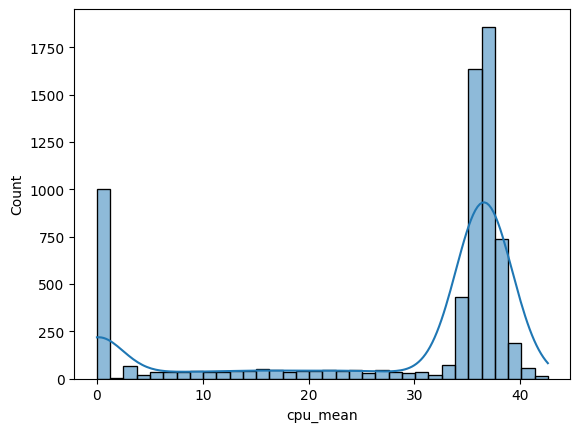

In [13]:
sns.histplot(data=dx10_cpu, x="cpu_mean", kde=True)
plt.show()

In [14]:
dx10_cpu.describe()

,timestamp,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
count,6942,6942.000000,6942.000000,6942.000000,6942.000000,6942.000000
mean,2026-05-27 15:06:05.339769,26.681893,31.081648,31.435825,25.578479,28.694461
min,2026-05-27 14:08:00.210622,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2026-05-27 14:37:02.817762,15.500000,17.200000,16.850000,15.525000,24.812500
50%,2026-05-27 15:06:05.495232,22.000000,27.700000,28.200000,21.600000,35.975000
75%,2026-05-27 15:35:07.832056,39.000000,45.900000,46.500000,36.600000,37.025000
max,2026-05-27 16:04:10.202686,93.800000,93.100000,94.000000,99.000000,42.600000
std,NaN,20.056778,22.328947,22.598488,18.889973,13.887965


In [15]:
threshold = dx10_cpu['cpu_mean'].quantile(0.95)
dx10_cpu[dx10_cpu['cpu_mean'] > threshold].describe()

,timestamp,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
count,347,347.000000,347.000000,347.000000,347.000000,347.000000
mean,2026-05-27 15:04:43.744853,37.752161,41.454467,43.204323,35.483285,39.473559
min,2026-05-27 14:08:09.445052,19.800000,18.600000,20.400000,19.600000,38.550000
25%,2026-05-27 14:37:22.613558,25.100000,28.200000,28.700000,25.100000,38.850000
50%,2026-05-27 15:02:01.814955,32.000000,37.900000,40.800000,30.700000,39.275000
75%,2026-05-27 15:33:29.159676,46.900000,51.500000,55.950000,43.600000,39.900000
max,2026-05-27 16:03:32.106987,92.900000,91.800000,89.700000,86.000000,42.600000
std,NaN,15.816004,16.019668,16.140915,13.264693,0.806981


### RAM

In [16]:
dx10_ram = pd.read_csv(f'{x10_folder_path}/mem.csv')
dx10_ram['timestamp'] = dx10_ram['timestamp'].apply(lambda x: datetime.fromisoformat(x))
dx10_ram.head()

,timestamp,total,available,used,percent,free,active,inactive,buffers,cached
0,2026-05-27 14:07:59.207231,17002643456,16413671424,588972032,3.5,15829778432,721240064,185860096,40124416,661946368
1,2026-05-27 14:08:00.210193,17002643456,16366272512,636370944,3.7,15779217408,756547584,187367424,40124416,664797184
2,2026-05-27 14:08:01.231215,17002643456,16289841152,712802304,4.2,15702786048,825622528,187367424,40124416,664797184
3,2026-05-27 14:08:02.396391,17002643456,16221896704,780746752,4.6,15634710528,883621888,187367424,40124416,664928256
4,2026-05-27 14:08:03.396902,17002643456,16089825280,912818176,5.4,15444262912,1004470272,246235136,40124416,724205568


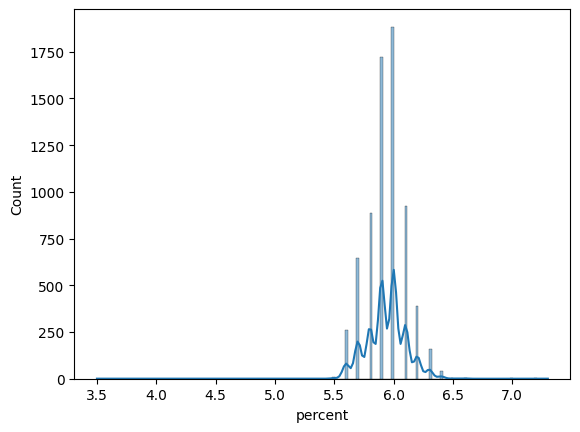

In [17]:
sns.histplot(data=dx10_ram, x="percent", kde=True)
plt.show()

In [18]:
dx10_ram.describe()

,timestamp,total,available,used,percent,free,active,inactive,buffers,cached
count,6950,6.950000e+03,6.950000e+03,6.950000e+03,6950.000000,6.950000e+03,6.950000e+03,6.950000e+03,6.950000e+03,6.950000e+03
mean,2026-05-27 15:06:05.050796,1.700264e+10,1.599261e+10,1.010031e+09,5.940532,1.524292e+10,1.183592e+09,3.460171e+08,4.066124e+07,8.270622e+08
min,2026-05-27 14:07:59.207231,1.700264e+10,1.575926e+10,5.889720e+08,3.500000,1.501007e+10,7.212401e+08,1.858601e+08,4.012442e+07,6.619464e+08
25%,2026-05-27 14:37:02.013352,1.700264e+10,1.597644e+10,9.935626e+08,5.800000,1.522664e+10,1.169682e+09,3.460301e+08,4.056678e+07,8.271790e+08
50%,2026-05-27 15:06:04.966610,1.700264e+10,1.599139e+10,1.011253e+09,5.900000,1.524154e+10,1.198817e+09,3.461448e+08,4.068147e+07,8.271790e+08
75%,2026-05-27 15:35:08.058041,1.700264e+10,1.600908e+10,1.026208e+09,6.000000,1.525933e+10,1.202717e+09,3.462595e+08,4.079616e+07,8.272118e+08
max,2026-05-27 16:04:11.000714,1.700264e+10,1.641367e+10,1.243382e+09,7.300000,1.582978e+10,1.208435e+09,3.468984e+08,4.091085e+07,8.279491e+08
std,NaN,0.000000e+00,2.895801e+07,2.895801e+07,0.172665,3.034293e+07,2.601746e+07,4.006029e+06,2.078320e+05,4.102976e+06


In [19]:
threshold = dx10_ram['percent'].quantile(0.95)
dx10_ram[dx10_ram['percent'] > threshold].describe()

,timestamp,total,available,used,percent,free,active,inactive,buffers,cached
count,216,2.160000e+02,2.160000e+02,2.160000e+02,216.000000,2.160000e+02,2.160000e+02,2.160000e+02,2.160000e+02,2.160000e+02
mean,2026-05-27 15:00:00.223168,1.700264e+10,1.592251e+10,1.080130e+09,6.362500,1.517276e+10,1.197175e+09,3.460741e+08,4.061381e+07,8.271591e+08
min,2026-05-27 14:08:07.399908,1.700264e+10,1.575926e+10,1.062683e+09,6.300000,1.501007e+10,1.137394e+09,3.455877e+08,4.014080e+07,8.269660e+08
25%,2026-05-27 14:28:55.776397,1.700264e+10,1.592172e+10,1.065943e+09,6.300000,1.517196e+10,1.198916e+09,3.459973e+08,4.053402e+07,8.271790e+08
50%,2026-05-27 15:05:11.834715,1.700264e+10,1.593258e+10,1.070064e+09,6.300000,1.518262e+10,1.201308e+09,3.461448e+08,4.068147e+07,8.271790e+08
75%,2026-05-27 15:29:02.036852,1.700264e+10,1.593670e+10,1.080926e+09,6.400000,1.518680e+10,1.203929e+09,3.462431e+08,4.077978e+07,8.272118e+08
max,2026-05-27 16:01:54.606039,1.700264e+10,1.593996e+10,1.243382e+09,7.300000,1.519049e+10,1.207222e+09,3.463741e+08,4.091085e+07,8.272118e+08
std,NaN,0.000000e+00,3.068145e+07,3.068145e+07,0.171806,3.055141e+07,1.327035e+07,2.449906e+05,2.392298e+05,7.906416e+04


### Power

In [20]:
dx10_power = pd.read_csv(f'{x10_folder_path}/power.csv')
dx10_power['timestamp'] = dx10_power['Datetime'].apply(lambda x: datetime.fromisoformat(x))
dx10_power.head()

,Datetime,Time[S],Volt[V],Current[A],Power[W],timestamp
0,2026-05-27T14:07:48.992947,0.0,5.1081,0.74170,3.7826,2026-05-27 14:07:48.992947
1,2026-05-27T14:07:50.013295,1.0,5.1081,0.88450,4.5109,2026-05-27 14:07:50.013295
2,2026-05-27T14:07:50.990313,2.0,5.1083,0.80242,4.0923,2026-05-27 14:07:50.990313
3,2026-05-27T14:07:52.011112,3.0,5.1081,0.80041,4.0820,2026-05-27 14:07:52.011112
4,2026-05-27T14:07:53.031963,4.0,5.1082,0.81588,4.1609,2026-05-27 14:07:53.031963


In [208]:
dx10_power = dx10_power.sort_values('timestamp')

# Time difference in hours
dx10_power['dt_hours'] = dx10_power['timestamp'].diff().dt.total_seconds() / 3600

# Energy (Wh)
dx10_power['energy_Wh'] = dx10_power['Power[W]'] * dx10_power['dt_hours']

# Total energy
total_energy_Wh = dx10_power['energy_Wh'].sum()

print("Total energy (Wh):", total_energy_Wh)

Total energy (Wh): 10.120193610011444


In [22]:
dx10_power.describe()

,Time[S],Volt[V],Current[A],Power[W],timestamp,dt_hours,energy_Wh
count,6987.000000,6987.000000,6987.000000,6987.000000,6987,6986.000000,6986.000000
mean,3493.669229,5.108061,1.021874,5.214013,2026-05-27 15:06:02.678649,0.000278,0.001449
min,0.000000,5.084700,0.589270,3.005200,2026-05-27 14:07:48.992947,0.000269,0.000813
25%,1746.800000,5.106100,0.984695,5.025450,2026-05-27 14:36:55.862129,0.000271,0.001379
50%,3493.700000,5.108500,1.060440,5.411700,2026-05-27 15:06:02.700103,0.000283,0.001503
75%,5240.500000,5.110400,1.132340,5.778550,2026-05-27 15:35:09.499741,0.000284,0.001605
max,6987.300000,5.123900,1.557660,7.928400,2026-05-27 16:04:16.358756,0.000286,0.002222
std,2017.498998,0.004550,0.182918,0.933477,NaN,0.000006,0.000261


## X2.0 ~ Batch | Baseline

passage_time: 10; interval: 3; window: 3

In [131]:
x20_folder_path = '../infra/reports/seq-batch_500'

### Predict

In [132]:
from pandas import json_normalize
import json

with open(f'{x20_folder_path}/metrics.json') as f:
    x20_data = json.load(f)

load_model_duration = datetime.fromisoformat(x20_data['load_model_final']) - datetime.fromisoformat(x20_data['load_model_start'])
    
rows = []
for animal, v1 in x20_data['animals'].items():
    row = {
        'pid': x20_data['pid'],
        'load_model_start': datetime.fromisoformat(x20_data['load_model_start']),
        'load_model_final': datetime.fromisoformat(x20_data['load_model_final']),
        'load_model_dur': load_model_duration,
        'animal':animal,
        'first_image_capture_time':datetime.fromisoformat(v1['first_image_capture_time']),
        'last_image_capture_time' :datetime.fromisoformat(v1['last_image_capture_time']),
        'display_time' :datetime.fromisoformat(v1['weight_prediction_final']),
        'total_of_images':v1['total_of_images'],
        'suitable_images':v1['suitable_images'],
    }
    
    for img, v2 in v1['imgs'].items():
        for k, v3 in v2.items():
            row[k] = datetime.fromisoformat(v3)

        rows.append(row)

dx20_metrics_v0 = pd.DataFrame.from_dict(rows)
dx20_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final
0,batch_2026-05-27T12:04:41.399957,2026-05-27 12:04:41.400656,2026-05-27 12:04:48.410428,0 days 00:00:07.009772,1,2026-05-27 12:04:48.410558,2026-05-27 12:04:57.554002,2026-05-27 12:04:59.872623,10,3,2026-05-27 12:04:58.555172,2026-05-27 12:04:59.872533
1,batch_2026-05-27T12:04:41.399957,2026-05-27 12:04:41.400656,2026-05-27 12:04:48.410428,0 days 00:00:07.009772,2,2026-05-27 12:05:02.872773,2026-05-27 12:05:11.909909,2026-05-27 12:05:14.228379,10,3,2026-05-27 12:05:12.906093,2026-05-27 12:05:14.228306
2,batch_2026-05-27T12:04:41.399957,2026-05-27 12:04:41.400656,2026-05-27 12:04:48.410428,0 days 00:00:07.009772,3,2026-05-27 12:05:17.229993,2026-05-27 12:05:26.288122,2026-05-27 12:05:28.627945,10,3,2026-05-27 12:05:27.287232,2026-05-27 12:05:28.627881
3,batch_2026-05-27T12:04:41.399957,2026-05-27 12:04:41.400656,2026-05-27 12:04:48.410428,0 days 00:00:07.009772,4,2026-05-27 12:05:31.629596,2026-05-27 12:05:40.665948,2026-05-27 12:05:42.935005,10,3,2026-05-27 12:05:41.640440,2026-05-27 12:05:42.934926
4,batch_2026-05-27T12:04:41.399957,2026-05-27 12:04:41.400656,2026-05-27 12:04:48.410428,0 days 00:00:07.009772,5,2026-05-27 12:05:45.936977,2026-05-27 12:05:55.021036,2026-05-27 12:05:57.304026,10,3,2026-05-27 12:05:56.006428,2026-05-27 12:05:57.303949


In [133]:
dx20_metrics_v0['by_animal_lead_time'] = dx20_metrics_v0['display_time'] - dx20_metrics_v0['first_image_capture_time']
dx20_metrics_v0['by_animal_processing_delay'] = dx20_metrics_v0['weight_prediction_final'] - dx20_metrics_v0['weight_prediction_start']
dx20_metrics_v0['by_animal_latency'] = dx20_metrics_v0['display_time'] - dx20_metrics_v0['last_image_capture_time']

dx20_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final,by_animal_lead_time,by_animal_processing_delay,by_animal_latency
0,batch_2026-05-27T12:04:41.399957,2026-05-27 12:04:41.400656,2026-05-27 12:04:48.410428,0 days 00:00:07.009772,1,2026-05-27 12:04:48.410558,2026-05-27 12:04:57.554002,2026-05-27 12:04:59.872623,10,3,2026-05-27 12:04:58.555172,2026-05-27 12:04:59.872533,0 days 00:00:11.462065,0 days 00:00:01.317361,0 days 00:00:02.318621
1,batch_2026-05-27T12:04:41.399957,2026-05-27 12:04:41.400656,2026-05-27 12:04:48.410428,0 days 00:00:07.009772,2,2026-05-27 12:05:02.872773,2026-05-27 12:05:11.909909,2026-05-27 12:05:14.228379,10,3,2026-05-27 12:05:12.906093,2026-05-27 12:05:14.228306,0 days 00:00:11.355606,0 days 00:00:01.322213,0 days 00:00:02.318470
2,batch_2026-05-27T12:04:41.399957,2026-05-27 12:04:41.400656,2026-05-27 12:04:48.410428,0 days 00:00:07.009772,3,2026-05-27 12:05:17.229993,2026-05-27 12:05:26.288122,2026-05-27 12:05:28.627945,10,3,2026-05-27 12:05:27.287232,2026-05-27 12:05:28.627881,0 days 00:00:11.397952,0 days 00:00:01.340649,0 days 00:00:02.339823
3,batch_2026-05-27T12:04:41.399957,2026-05-27 12:04:41.400656,2026-05-27 12:04:48.410428,0 days 00:00:07.009772,4,2026-05-27 12:05:31.629596,2026-05-27 12:05:40.665948,2026-05-27 12:05:42.935005,10,3,2026-05-27 12:05:41.640440,2026-05-27 12:05:42.934926,0 days 00:00:11.305409,0 days 00:00:01.294486,0 days 00:00:02.269057
4,batch_2026-05-27T12:04:41.399957,2026-05-27 12:04:41.400656,2026-05-27 12:04:48.410428,0 days 00:00:07.009772,5,2026-05-27 12:05:45.936977,2026-05-27 12:05:55.021036,2026-05-27 12:05:57.304026,10,3,2026-05-27 12:05:56.006428,2026-05-27 12:05:57.303949,0 days 00:00:11.367049,0 days 00:00:01.297521,0 days 00:00:02.282990


In [134]:
collect_lead_time = dx20_metrics_v0['display_time'].max() - dx20_metrics_v0['first_image_capture_time'].min()
qtt = len(dx20_metrics_v0['animal'].unique())

dx20_metrics_v0['collect_lead_time'] = collect_lead_time
dx20_metrics_v0['mean_throughput'] = qtt / (collect_lead_time.total_seconds() / 60 / 60) # hour

dx20_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final,by_animal_lead_time,by_animal_processing_delay,by_animal_latency,collect_lead_time,mean_throughput
0,batch_2026-05-27T12:04:41.399957,2026-05-27 12:04:41.400656,2026-05-27 12:04:48.410428,0 days 00:00:07.009772,1,2026-05-27 12:04:48.410558,2026-05-27 12:04:57.554002,2026-05-27 12:04:59.872623,10,3,2026-05-27 12:04:58.555172,2026-05-27 12:04:59.872533,0 days 00:00:11.462065,0 days 00:00:01.317361,0 days 00:00:02.318621,0 days 02:01:46.150859,246.367757
1,batch_2026-05-27T12:04:41.399957,2026-05-27 12:04:41.400656,2026-05-27 12:04:48.410428,0 days 00:00:07.009772,2,2026-05-27 12:05:02.872773,2026-05-27 12:05:11.909909,2026-05-27 12:05:14.228379,10,3,2026-05-27 12:05:12.906093,2026-05-27 12:05:14.228306,0 days 00:00:11.355606,0 days 00:00:01.322213,0 days 00:00:02.318470,0 days 02:01:46.150859,246.367757
2,batch_2026-05-27T12:04:41.399957,2026-05-27 12:04:41.400656,2026-05-27 12:04:48.410428,0 days 00:00:07.009772,3,2026-05-27 12:05:17.229993,2026-05-27 12:05:26.288122,2026-05-27 12:05:28.627945,10,3,2026-05-27 12:05:27.287232,2026-05-27 12:05:28.627881,0 days 00:00:11.397952,0 days 00:00:01.340649,0 days 00:00:02.339823,0 days 02:01:46.150859,246.367757
3,batch_2026-05-27T12:04:41.399957,2026-05-27 12:04:41.400656,2026-05-27 12:04:48.410428,0 days 00:00:07.009772,4,2026-05-27 12:05:31.629596,2026-05-27 12:05:40.665948,2026-05-27 12:05:42.935005,10,3,2026-05-27 12:05:41.640440,2026-05-27 12:05:42.934926,0 days 00:00:11.305409,0 days 00:00:01.294486,0 days 00:00:02.269057,0 days 02:01:46.150859,246.367757
4,batch_2026-05-27T12:04:41.399957,2026-05-27 12:04:41.400656,2026-05-27 12:04:48.410428,0 days 00:00:07.009772,5,2026-05-27 12:05:45.936977,2026-05-27 12:05:55.021036,2026-05-27 12:05:57.304026,10,3,2026-05-27 12:05:56.006428,2026-05-27 12:05:57.303949,0 days 00:00:11.367049,0 days 00:00:01.297521,0 days 00:00:02.282990,0 days 02:01:46.150859,246.367757


In [135]:
dx20_metrics_v0[['total_of_images', 'suitable_images', 'by_animal_processing_delay', 'by_animal_latency', 'mean_throughput']].describe()

,total_of_images,suitable_images,by_animal_processing_delay,by_animal_latency,mean_throughput
count,500.000000,500.000000,500,500,5.000000e+02
mean,10.266000,3.080000,0 days 00:00:01.332668,0 days 00:00:02.327110,2.463678e+02
std,0.442307,0.271565,0 days 00:00:00.060980,0 days 00:00:00.061960,5.690035e-14
min,10.000000,3.000000,0 days 00:00:01.286716,0 days 00:00:02.265735,2.463678e+02
25%,10.000000,3.000000,0 days 00:00:01.307429,0 days 00:00:02.301681,2.463678e+02
50%,10.000000,3.000000,0 days 00:00:01.316070,0 days 00:00:02.310968,2.463678e+02
75%,11.000000,3.000000,0 days 00:00:01.325575,0 days 00:00:02.321659,2.463678e+02
max,11.000000,4.000000,0 days 00:00:01.564779,0 days 00:00:02.566895,2.463678e+02


In [136]:
total_processing_delay = dx20_metrics_v0['by_animal_processing_delay'].sum()
total_processing_delay

Timedelta('0 days 00:11:06.334242')

In [137]:
total_of_imgs = dx20_metrics_v0['total_of_images'].sum()
suitable_imgs = dx20_metrics_v0['suitable_images'].sum()

total_time = pd.to_timedelta(dx20_metrics_v0['collect_lead_time'].unique()[0])

print(f'{int(total_of_imgs)} images in {total_time} => {(total_of_imgs / total_time.total_seconds()):.2f} FPS;')
print(f'{int(suitable_imgs)} images in {total_processing_delay} => {(suitable_imgs / total_processing_delay.total_seconds()):.2f} FPS;')
print(f'{(total_processing_delay.total_seconds() / total_time.total_seconds() * 100):.2f}% with inference;')

5133 images in 0 days 02:01:46.150859 => 0.70 FPS;
1540 images in 0 days 00:11:06.334242 => 2.31 FPS;
9.12% with inference;


### CPU

In [31]:
dx20_cpu = pd.read_csv(f'{x20_folder_path}/cpu.csv')

dx20_cpu['timestamp'] = dx20_cpu['timestamp'].apply(lambda x: datetime.fromisoformat(x))
dx20_cpu['cpu_mean']  = dx20_cpu[['cpu_core_0', 'cpu_core_1', 'cpu_core_2', 'cpu_core_3']].mean(axis=1)

dx20_cpu.head()

,timestamp,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
0,2026-05-27 12:04:42.401666,31.0,43.0,3.0,27.7,26.175
1,2026-05-27 12:04:43.407382,65.0,21.8,29.7,11.0,31.875
2,2026-05-27 12:04:44.408204,100.0,0.0,0.0,0.0,25.000
3,2026-05-27 12:04:45.408606,57.0,0.0,0.0,0.0,14.250
4,2026-05-27 12:04:46.408975,3.0,0.0,0.0,0.0,0.750


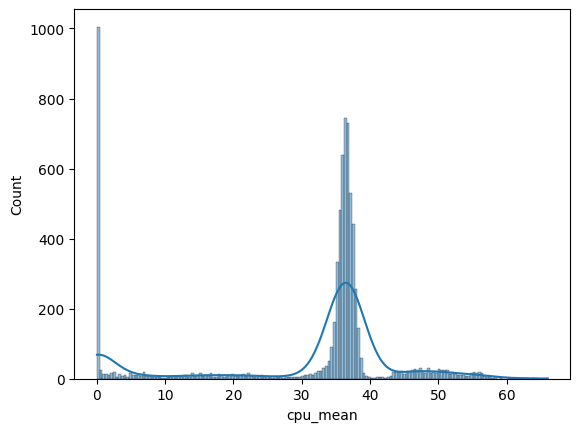

In [32]:
sns.histplot(data=dx20_cpu, x="cpu_mean", kde=True)
plt.show()

In [33]:
dx20_cpu.describe()

,timestamp,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
count,7290,7290.000000,7290.000000,7290.000000,7290.000000,7290.000000
mean,2026-05-27 13:05:39.541201,29.559342,32.693937,33.220919,26.720384,30.548645
min,2026-05-27 12:04:42.401666,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2026-05-27 12:35:10.889277,16.700000,17.300000,18.000000,16.500000,33.400000
50%,2026-05-27 13:05:39.384134,24.500000,31.000000,31.600000,22.200000,36.175000
75%,2026-05-27 13:36:08.102571,44.000000,48.400000,49.500000,39.200000,37.225000
max,2026-05-27 14:06:37.114962,100.000000,93.800000,100.000000,91.900000,66.050000
std,NaN,21.327245,22.740343,22.848504,18.655599,15.001729


In [34]:
threshold = dx20_cpu['cpu_mean'].quantile(0.95)
dx20_cpu[dx20_cpu['cpu_mean'] > threshold].describe()

,timestamp,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
count,364,364.000000,364.000000,364.000000,364.000000,364.000000
mean,2026-05-27 13:05:28.589943,53.017582,54.208791,54.890385,52.186813,53.575893
min,2026-05-27 12:04:59.428209,31.700000,36.100000,34.400000,34.700000,49.300000
25%,2026-05-27 12:35:34.446363,45.500000,47.300000,47.975000,46.000000,50.900000
50%,2026-05-27 13:05:41.390088,52.050000,53.150000,53.700000,51.600000,52.762500
75%,2026-05-27 13:35:13.137986,60.000000,60.050000,61.250000,57.400000,55.743750
max,2026-05-27 14:06:34.109773,79.000000,80.000000,86.000000,91.900000,66.050000
std,NaN,9.536863,9.031377,9.777581,8.785130,3.266998


### RAM

In [35]:
dx20_ram = pd.read_csv(f'{x20_folder_path}/mem.csv')
dx20_ram['timestamp'] = dx20_ram['timestamp'].apply(lambda x: datetime.fromisoformat(x))
dx20_ram.head()

,timestamp,total,available,used,percent,free,active,inactive,buffers,cached
0,2026-05-27 12:04:41.400848,17002643456,16362684416,639959040,3.8,15778545664,721223680,186023936,40026112,662044672
1,2026-05-27 12:04:42.401381,17002643456,16316727296,685916160,4.0,15729688576,756269056,187269120,40026112,664895488
2,2026-05-27 12:04:43.407104,17002643456,16245948416,756695040,4.5,15658909696,824328192,187269120,40026112,664895488
3,2026-05-27 12:04:44.407922,17002643456,16233889792,768753664,4.5,15646720000,853344256,187269120,40026112,665026560
4,2026-05-27 12:04:45.408293,17002643456,16088236032,914407424,5.4,15458009088,989036544,230309888,40026112,708575232


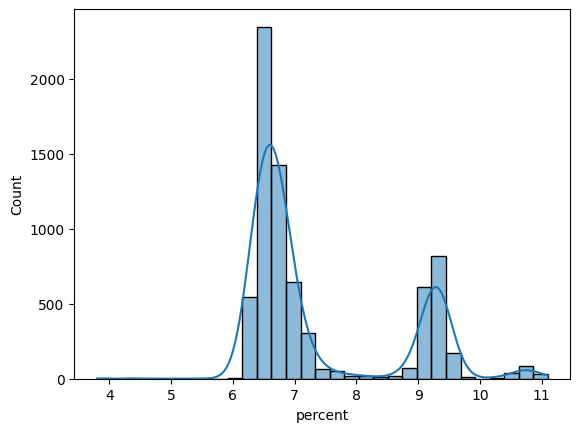

In [36]:
sns.histplot(data=dx20_ram, x="percent", kde=True)
plt.show()

In [37]:
dx20_ram.describe()

,timestamp,total,available,used,percent,free,active,inactive,buffers,cached
count,7297,7.297000e+03,7.297000e+03,7.297000e+03,7297.000000,7.297000e+03,7.297000e+03,7.297000e+03,7.297000e+03,7.297000e+03
mean,2026-05-27 13:05:39.721656,1.700264e+10,1.575104e+10,1.251602e+09,7.361642,1.500120e+10,1.332430e+09,3.459261e+08,4.057035e+07,8.273233e+08
min,2026-05-27 12:04:41.400848,1.700264e+10,1.511740e+10,6.399590e+08,3.800000,1.436756e+10,7.212237e+08,1.860239e+08,4.002611e+07,6.620447e+08
25%,2026-05-27 12:35:10.564535,1.700264e+10,1.550329e+10,1.108083e+09,6.500000,1.475337e+10,1.205453e+09,3.459809e+08,4.051763e+07,8.274575e+08
50%,2026-05-27 13:05:39.799548,1.700264e+10,1.585601e+10,1.146634e+09,6.700000,1.510605e+10,1.208451e+09,3.460956e+08,4.063232e+07,8.274575e+08
75%,2026-05-27 13:36:08.885977,1.700264e+10,1.589456e+10,1.499349e+09,8.800000,1.514463e+10,1.591804e+09,3.461939e+08,4.073062e+07,8.274575e+08
max,2026-05-27 14:06:38.117485,1.700264e+10,1.636268e+10,1.885241e+09,11.100000,1.577855e+10,1.901887e+09,3.465380e+08,4.082893e+07,8.281129e+08
std,NaN,0.000000e+00,2.104064e+08,2.104064e+08,1.237551,2.107065e+08,2.085772e+08,3.976290e+06,2.071933e+05,4.078120e+06


In [38]:
threshold = dx20_ram['percent'].quantile(0.95)
dx20_ram[dx20_ram['percent'] > threshold].describe()

,timestamp,total,available,used,percent,free,active,inactive,buffers,cached
count,340,3.400000e+02,3.400000e+02,3.400000e+02,340.000000,3.400000e+02,3.400000e+02,3.400000e+02,3.400000e+02,3.400000e+02
mean,2026-05-27 13:07:10.117507,1.700264e+10,1.528815e+10,1.714492e+09,10.091471,1.453820e+10,1.770002e+09,3.460296e+08,4.056765e+07,8.274305e+08
min,2026-05-27 12:05:00.425765,1.700264e+10,1.511740e+10,1.606910e+09,9.500000,1.436756e+10,1.663910e+09,3.454894e+08,4.004250e+07,8.272445e+08
25%,2026-05-27 12:35:01.297899,1.700264e+10,1.517593e+10,1.614844e+09,9.500000,1.442600e+10,1.670529e+09,3.459809e+08,4.051763e+07,8.274575e+08
50%,2026-05-27 13:08:55.242539,1.700264e+10,1.536280e+10,1.639842e+09,9.600000,1.461308e+10,1.676845e+09,3.460956e+08,4.063232e+07,8.274575e+08
75%,2026-05-27 13:36:18.155729,1.700264e+10,1.538780e+10,1.826718e+09,10.700000,1.463806e+10,1.890251e+09,3.461939e+08,4.073062e+07,8.274575e+08
max,2026-05-27 14:06:38.117485,1.700264e+10,1.539573e+10,1.885241e+09,11.100000,1.464571e+10,1.901887e+09,3.465380e+08,4.082893e+07,8.281129e+08
std,NaN,0.000000e+00,1.044558e+08,1.044558e+08,0.607634,1.044840e+08,1.060496e+08,2.324208e+05,2.265573e+05,8.215335e+04


### Power

In [39]:
dx20_power = pd.read_csv(f'{x20_folder_path}/power.csv')
dx20_power['timestamp'] = dx20_power['Datetime'].apply(lambda x: datetime.fromisoformat(x))
dx20_power.head()

,Datetime,Time[S],Volt[V],Current[A],Power[W],timestamp
0,2026-05-27T12:04:30.412520,0.0,5.1079,0.58434,2.9801,2026-05-27 12:04:30.412520
1,2026-05-27T12:04:31.382646,1.0,5.1075,0.59841,3.0518,2026-05-27 12:04:31.382646
2,2026-05-27T12:04:32.403444,2.0,5.1069,0.85022,4.3361,2026-05-27 12:04:32.403444
3,2026-05-27T12:04:33.375640,3.0,5.1071,0.84955,4.3327,2026-05-27 12:04:33.375640
4,2026-05-27T12:04:34.396404,4.0,5.1070,0.91297,4.6561,2026-05-27 12:04:34.396404


In [209]:
dx20_power = dx20_power.sort_values('timestamp')

# Time difference in hours
dx20_power['dt_hours'] = dx20_power['timestamp'].diff().dt.total_seconds() / 3600

# Energy (Wh)
dx20_power['energy_Wh'] = dx20_power['Power[W]'] * dx20_power['dt_hours']

# Total energy
total_energy_Wh = dx20_power['energy_Wh'].sum()

print("Total energy (Wh):", total_energy_Wh)

Total energy (Wh): 10.87022253446439


In [41]:
dx20_power.describe()

,Time[S],Volt[V],Current[A],Power[W],timestamp,dt_hours,energy_Wh
count,7330.000000,7330.000000,7330.000000,7330.000000,7330,7329.000000,7329.000000
mean,3665.267299,5.106856,1.046394,5.337921,2026-05-27 13:05:35.656657,0.000278,0.001483
min,0.000000,5.075100,0.584340,2.980100,2026-05-27 12:04:30.412520,0.000269,0.000820
25%,1832.650000,5.104500,0.988838,5.043325,2026-05-27 12:35:03.019830,0.000271,0.001386
50%,3665.300000,5.107500,1.071875,5.467400,2026-05-27 13:05:35.654700,0.000283,0.001518
75%,5497.950000,5.109400,1.156938,5.901525,2026-05-27 13:36:08.283909,0.000284,0.001644
max,7330.500000,5.131400,1.734680,8.794800,2026-05-27 14:06:40.887047,0.000286,0.002498
std,2116.578154,0.005027,0.183988,0.938670,NaN,0.000006,0.000263


## X2.1

passage_time: 5; interval: 3; window: 3

In [39]:
x21_folder_path = '../infra/reports/batch_x21'

### Predict

In [40]:
from pandas import json_normalize
import json

with open(f'{x21_folder_path}/metrics.json') as f:
    x21_data = json.load(f)

load_model_duration = datetime.fromisoformat(x21_data['load_model_final']) - datetime.fromisoformat(x21_data['load_model_start'])
    
rows = []
for animal, v1 in x21_data['animals'].items():
    row = {
        'pid': x21_data['pid'],
        'load_model_start': datetime.fromisoformat(x21_data['load_model_start']),
        'load_model_final': datetime.fromisoformat(x21_data['load_model_final']),
        'load_model_dur': load_model_duration,
        'animal':animal,
        'first_image_capture_time':datetime.fromisoformat(v1['first_image_capture_time']),
        'last_image_capture_time' :datetime.fromisoformat(v1['last_image_capture_time']),
        'display_time' :datetime.fromisoformat(v1['weight_prediction_final']),
        'total_of_images':v1['total_of_images'],
        'suitable_images':v1['suitable_images'],    
    }
    
    
    for img, v2 in v1['imgs'].items():
        for k, v3 in v2.items():
            row[k] = datetime.fromisoformat(v3)

        rows.append(row)

dx21_metrics_v0 = pd.DataFrame.from_dict(rows)
dx21_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final
0,batch_2026-04-17T17:05:50.203887,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,1,2026-04-17 17:05:57.231821,2026-04-17 17:06:01.410884,2026-04-17 17:06:03.742907,5,3,2026-04-17 17:06:02.419459,2026-04-17 17:06:03.742819
1,batch_2026-04-17T17:05:50.203887,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,2,2026-04-17 17:06:06.743041,2026-04-17 17:06:10.796294,2026-04-17 17:06:13.081174,5,3,2026-04-17 17:06:11.784023,2026-04-17 17:06:13.081105
2,batch_2026-04-17T17:05:50.203887,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,3,2026-04-17 17:06:16.082067,2026-04-17 17:06:20.091644,2026-04-17 17:06:22.441256,5,3,2026-04-17 17:06:21.102229,2026-04-17 17:06:22.441184
3,batch_2026-04-17T17:05:50.203887,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,4,2026-04-17 17:06:25.442878,2026-04-17 17:06:29.477876,2026-04-17 17:06:31.790001,5,3,2026-04-17 17:06:30.485137,2026-04-17 17:06:31.789921
4,batch_2026-04-17T17:05:50.203887,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,5,2026-04-17 17:06:34.791963,2026-04-17 17:06:38.816524,2026-04-17 17:06:41.118891,5,3,2026-04-17 17:06:39.809684,2026-04-17 17:06:41.118814


In [41]:
dx21_metrics_v0['by_animal_lead_time'] = dx21_metrics_v0['display_time'] - dx21_metrics_v0['first_image_capture_time']
dx21_metrics_v0['by_animal_processing_delay'] = dx21_metrics_v0['weight_prediction_final'] - dx21_metrics_v0['weight_prediction_start']
dx21_metrics_v0['by_animal_latency'] = dx21_metrics_v0['display_time'] - dx21_metrics_v0['last_image_capture_time']

dx21_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final,by_animal_lead_time,by_animal_processing_delay,by_animal_latency
0,batch_2026-04-17T17:05:50.203887,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,1,2026-04-17 17:05:57.231821,2026-04-17 17:06:01.410884,2026-04-17 17:06:03.742907,5,3,2026-04-17 17:06:02.419459,2026-04-17 17:06:03.742819,0 days 00:00:06.511086,0 days 00:00:01.323360,0 days 00:00:02.332023
1,batch_2026-04-17T17:05:50.203887,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,2,2026-04-17 17:06:06.743041,2026-04-17 17:06:10.796294,2026-04-17 17:06:13.081174,5,3,2026-04-17 17:06:11.784023,2026-04-17 17:06:13.081105,0 days 00:00:06.338133,0 days 00:00:01.297082,0 days 00:00:02.284880
2,batch_2026-04-17T17:05:50.203887,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,3,2026-04-17 17:06:16.082067,2026-04-17 17:06:20.091644,2026-04-17 17:06:22.441256,5,3,2026-04-17 17:06:21.102229,2026-04-17 17:06:22.441184,0 days 00:00:06.359189,0 days 00:00:01.338955,0 days 00:00:02.349612
3,batch_2026-04-17T17:05:50.203887,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,4,2026-04-17 17:06:25.442878,2026-04-17 17:06:29.477876,2026-04-17 17:06:31.790001,5,3,2026-04-17 17:06:30.485137,2026-04-17 17:06:31.789921,0 days 00:00:06.347123,0 days 00:00:01.304784,0 days 00:00:02.312125
4,batch_2026-04-17T17:05:50.203887,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,5,2026-04-17 17:06:34.791963,2026-04-17 17:06:38.816524,2026-04-17 17:06:41.118891,5,3,2026-04-17 17:06:39.809684,2026-04-17 17:06:41.118814,0 days 00:00:06.326928,0 days 00:00:01.309130,0 days 00:00:02.302367


In [42]:
collect_lead_time = dx21_metrics_v0['display_time'].max() - dx21_metrics_v0['first_image_capture_time'].min()
qtt = len(dx21_metrics_v0['animal'].unique())

dx21_metrics_v0['collect_lead_time'] = collect_lead_time
dx21_metrics_v0['mean_throughput'] = qtt / (collect_lead_time.total_seconds() / 60 / 60) # hour

dx21_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final,by_animal_lead_time,by_animal_processing_delay,by_animal_latency,collect_lead_time,mean_throughput
0,batch_2026-04-17T17:05:50.203887,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,1,2026-04-17 17:05:57.231821,2026-04-17 17:06:01.410884,2026-04-17 17:06:03.742907,5,3,2026-04-17 17:06:02.419459,2026-04-17 17:06:03.742819,0 days 00:00:06.511086,0 days 00:00:01.323360,0 days 00:00:02.332023,0 days 00:15:39.570844,383.153652
1,batch_2026-04-17T17:05:50.203887,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,2,2026-04-17 17:06:06.743041,2026-04-17 17:06:10.796294,2026-04-17 17:06:13.081174,5,3,2026-04-17 17:06:11.784023,2026-04-17 17:06:13.081105,0 days 00:00:06.338133,0 days 00:00:01.297082,0 days 00:00:02.284880,0 days 00:15:39.570844,383.153652
2,batch_2026-04-17T17:05:50.203887,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,3,2026-04-17 17:06:16.082067,2026-04-17 17:06:20.091644,2026-04-17 17:06:22.441256,5,3,2026-04-17 17:06:21.102229,2026-04-17 17:06:22.441184,0 days 00:00:06.359189,0 days 00:00:01.338955,0 days 00:00:02.349612,0 days 00:15:39.570844,383.153652
3,batch_2026-04-17T17:05:50.203887,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,4,2026-04-17 17:06:25.442878,2026-04-17 17:06:29.477876,2026-04-17 17:06:31.790001,5,3,2026-04-17 17:06:30.485137,2026-04-17 17:06:31.789921,0 days 00:00:06.347123,0 days 00:00:01.304784,0 days 00:00:02.312125,0 days 00:15:39.570844,383.153652
4,batch_2026-04-17T17:05:50.203887,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,5,2026-04-17 17:06:34.791963,2026-04-17 17:06:38.816524,2026-04-17 17:06:41.118891,5,3,2026-04-17 17:06:39.809684,2026-04-17 17:06:41.118814,0 days 00:00:06.326928,0 days 00:00:01.309130,0 days 00:00:02.302367,0 days 00:15:39.570844,383.153652


In [43]:
dx21_metrics_v0.describe()

,load_model_start,load_model_final,load_model_dur,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final,by_animal_lead_time,by_animal_processing_delay,by_animal_latency,collect_lead_time,mean_throughput
count,100,100,100,100,100,100,100.000000,100.000000,100,100,100,100,100,100,1.000000e+02
mean,2026-04-17 17:05:50.204716,2026-04-17 17:05:57.231725,0 days 00:00:07.027009,2026-04-17 17:13:43.209451,2026-04-17 17:13:47.307275,2026-04-17 17:13:49.633486,5.050000,3.030000,2026-04-17 17:13:48.307731,2026-04-17 17:13:49.633414,0 days 00:00:06.424034,0 days 00:00:01.325684,0 days 00:00:02.326210,0 days 00:15:39.570844,3.831537e+02
min,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,2026-04-17 17:05:57.231821,2026-04-17 17:06:01.410884,2026-04-17 17:06:03.742907,5.000000,3.000000,2026-04-17 17:06:02.419459,2026-04-17 17:06:03.742819,0 days 00:00:06.308333,0 days 00:00:01.295961,0 days 00:00:02.274947,0 days 00:15:39.570844,3.831537e+02
25%,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,2026-04-17 17:09:49.113864,2026-04-17 17:09:53.165715,2026-04-17 17:09:55.488441,5.000000,3.000000,2026-04-17 17:09:54.164659,2026-04-17 17:09:55.488374,0 days 00:00:06.352670,0 days 00:00:01.312570,0 days 00:00:02.311899,0 days 00:15:39.570844,3.831537e+02
50%,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,2026-04-17 17:13:42.918230,2026-04-17 17:13:46.955722,2026-04-17 17:13:49.276482,5.000000,3.000000,2026-04-17 17:13:47.952066,2026-04-17 17:13:49.276416,0 days 00:00:06.375167,0 days 00:00:01.319465,0 days 00:00:02.320001,0 days 00:15:39.570844,3.831537e+02
75%,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,2026-04-17 17:17:37.258679,2026-04-17 17:17:41.305273,2026-04-17 17:17:43.624967,5.000000,3.000000,2026-04-17 17:17:42.308529,2026-04-17 17:17:43.624888,0 days 00:00:06.388513,0 days 00:00:01.328601,0 days 00:00:02.332950,0 days 00:15:39.570844,3.831537e+02
max,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,2026-04-17 17:21:30.453131,2026-04-17 17:21:34.483733,2026-04-17 17:21:36.802665,6.000000,4.000000,2026-04-17 17:21:35.484898,2026-04-17 17:21:36.802589,0 days 00:00:07.541387,0 days 00:00:01.540708,0 days 00:00:02.542671,0 days 00:15:39.570844,3.831537e+02
std,NaN,NaN,0 days 00:00:00,NaN,NaN,NaN,0.219043,0.171447,NaN,NaN,0 days 00:00:00.237602,0 days 00:00:00.037659,0 days 00:00:00.040480,0 days 00:00:00,1.142596e-13


In [44]:
dx21_metrics_v0['by_animal_processing_delay'].sum()

Timedelta('0 days 00:02:12.568420')

In [45]:
total_of_imgs = dx21_metrics_v0['total_of_images'].sum()
total_time = pd.to_timedelta(dx21_metrics_v0['collect_lead_time'].unique()[0])

print(f'Imgs: {total_of_imgs} - Time: {total_time} => FPS:{total_of_imgs / total_time.total_seconds()}')

Imgs: 505 - Time: 0 days 00:15:39.570844 => FPS:0.5374794282143561


### CPU

In [46]:
dx21_cpu = pd.read_csv(f'{x21_folder_path}/cpu.csv')

dx21_cpu['timestamp'] = dx21_cpu['timestamp'].apply(lambda x: datetime.fromisoformat(x))
dx21_cpu['cpu_mean']  = dx21_cpu[['cpu_core_0', 'cpu_core_1', 'cpu_core_2', 'cpu_core_3']].mean(axis=1)

dx21_cpu.head()

,timestamp,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
0,2026-04-17 17:05:51.205827,2.0,2.0,95.0,2.0,25.250
1,2026-04-17 17:05:52.236993,34.7,15.8,28.4,46.6,31.375
2,2026-04-17 17:05:53.403491,100.0,0.9,0.9,1.7,25.875
3,2026-04-17 17:05:54.404129,35.0,1.0,1.0,0.0,9.250
4,2026-04-17 17:05:55.404549,4.0,0.0,0.0,1.0,1.250


In [47]:
dx21_cpu.describe()

,timestamp,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
count,946,946.000000,946.000000,946.000000,946.000000,946.000000
mean,2026-04-17 17:13:45.561720,27.042178,28.093129,28.242495,24.538161,26.978990
min,2026-04-17 17:05:51.205827,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2026-04-17 17:09:48.527147,5.000000,3.000000,4.000000,5.000000,5.868750
50%,2026-04-17 17:13:45.584545,21.200000,23.800000,23.600000,20.000000,35.400000
75%,2026-04-17 17:17:42.538971,43.900000,45.750000,45.400000,39.200000,37.075000
max,2026-04-17 17:21:39.720399,100.000000,93.800000,95.000000,92.900000,61.275000
std,NaN,23.262456,23.723330,23.637107,20.649589,17.629036


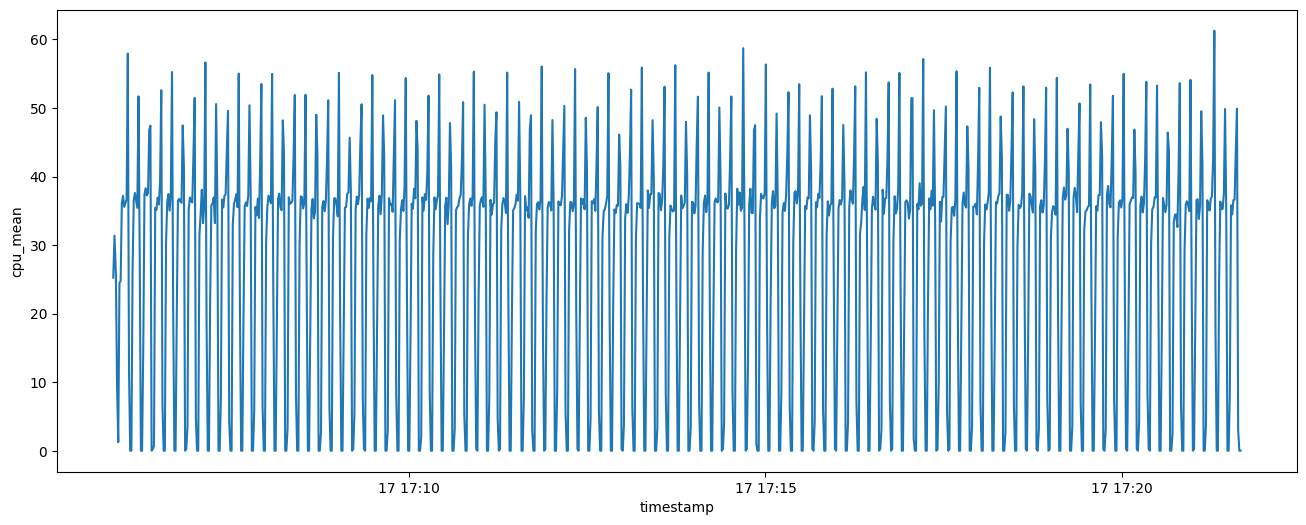

In [48]:
plt.figure(figsize=(16, 6))
sns.lineplot(data=dx21_cpu.sort_values(by='timestamp'), x="timestamp", y="cpu_mean")
plt.show()

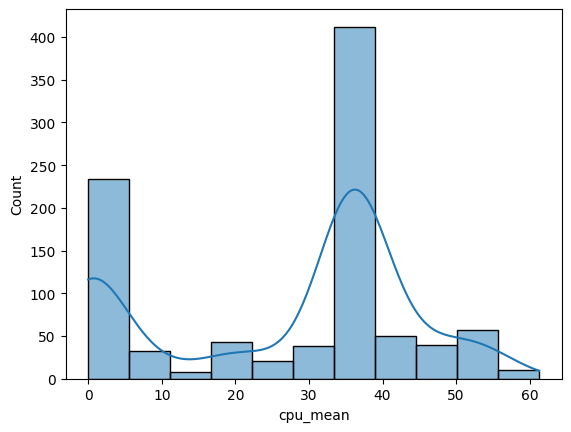

In [49]:
sns.histplot(data=dx21_cpu, x="cpu_mean", kde=True)
plt.show()

### RAM

In [50]:
dx21_ram = pd.read_csv(f'{x21_folder_path}/mem.csv')
dx21_ram['timestamp'] = dx21_ram['timestamp'].apply(lambda x: datetime.fromisoformat(x))
dx21_ram.head()

,timestamp,total,available,used,percent,free,active,inactive,buffers,cached
0,2026-04-17 17:05:50.205030,17002643456,16456679424,545964032,3.2,15874048000,720666624,184582144,38502400,661913600
1,2026-04-17 17:05:51.205898,17002643456,16418570240,584073216,3.4,15833497600,756088832,185384960,38502400,664436736
2,2026-04-17 17:05:52.221525,17002643456,16327884800,674758656,4.0,15742812160,825163776,185384960,38502400,664436736
3,2026-04-17 17:05:53.221838,17002643456,16275423232,727220224,4.3,15690219520,859160576,185384960,38502400,664567808
4,2026-04-17 17:05:54.222319,17002643456,16103407616,899235840,5.3,15471001600,991674368,232570880,38502400,712048640


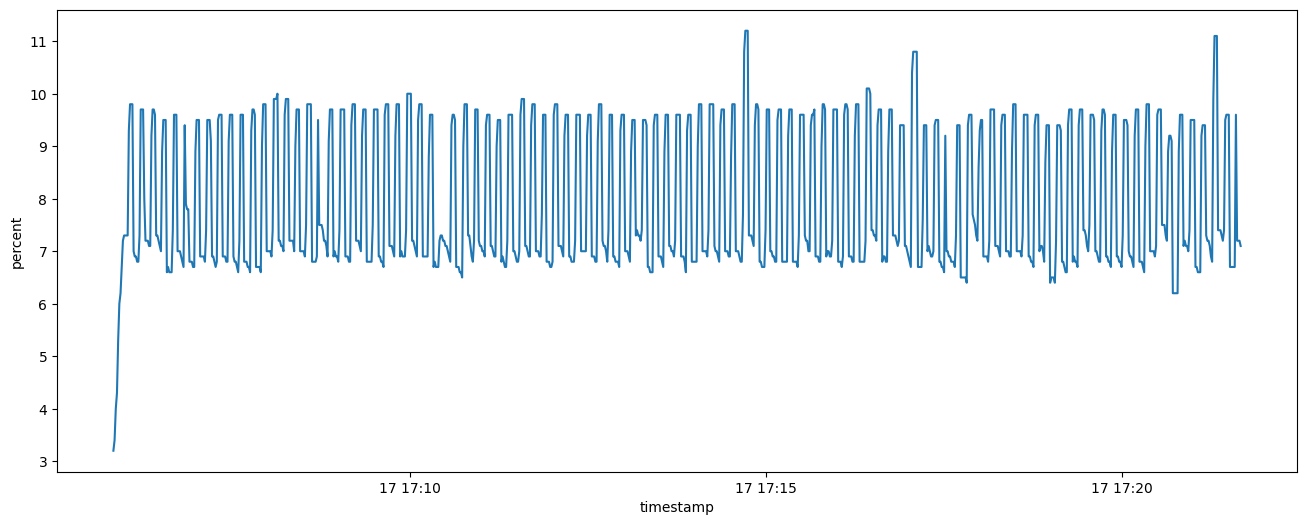

In [51]:
plt.figure(figsize=(16, 6))
sns.lineplot(data=dx21_ram.sort_values(by='timestamp'), x="timestamp", y="percent")
plt.show()

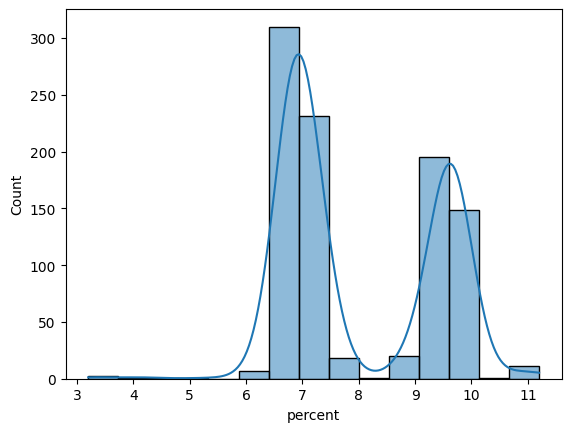

In [52]:
sns.histplot(data=dx21_ram, x="percent", kde=True)
plt.show()

In [53]:
dx21_ram.describe()

,timestamp,total,available,used,percent,free,active,inactive,buffers,cached
count,948,9.480000e+02,9.480000e+02,9.480000e+02,948.000000,9.480000e+02,9.480000e+02,9.480000e+02,9.480000e+02,9.480000e+02
mean,2026-04-17 17:13:45.216960,1.700264e+10,1.564315e+10,1.359498e+09,7.994831,1.489641e+10,1.401040e+09,3.429885e+08,3.870051e+07,8.260049e+08
min,2026-04-17 17:05:50.205030,1.700264e+10,1.509900e+10,5.459640e+08,3.200000,1.435163e+10,7.206666e+08,1.845821e+08,3.850240e+07,6.619136e+08
25%,2026-04-17 17:09:47.659589,1.700264e+10,1.537224e+10,1.167315e+09,6.900000,1.462482e+10,1.201111e+09,3.436216e+08,3.853517e+07,8.267694e+08
50%,2026-04-17 17:13:45.209436,1.700264e+10,1.578042e+10,1.222222e+09,7.200000,1.503272e+10,1.202946e+09,3.436216e+08,3.853517e+07,8.267694e+08
75%,2026-04-17 17:17:42.702847,1.700264e+10,1.583533e+10,1.630401e+09,9.600000,1.508764e+10,1.700053e+09,3.440968e+08,3.899392e+07,8.269824e+08
max,2026-04-17 17:21:40.399020,1.700264e+10,1.645668e+10,1.903641e+09,11.200000,1.587405e+10,1.932345e+09,3.441132e+08,3.901030e+07,8.270971e+08
std,NaN,0.000000e+00,2.330065e+08,2.330065e+08,1.367338,2.356923e+08,2.462381e+08,1.090829e+07,2.261721e+05,1.121959e+07


### Power

In [54]:
dx21_power = pd.read_csv(f'{x21_folder_path}/power.csv')
dx21_power['timestamp'] = dx21_power['Datetime'].apply(lambda x: datetime.fromisoformat(x))
dx21_power.head()

,Datetime,Time[S],Volt[V],Current[A],Power[W],timestamp
0,2026-04-17T17:05:39.967578,0.0,5.1089,0.55677,2.8395,2026-04-17 17:05:39.967578
1,2026-04-17T17:05:40.936425,1.0,5.1059,0.74729,3.8111,2026-04-17 17:05:40.936425
2,2026-04-17T17:05:41.953576,2.0,5.1088,0.77907,3.9732,2026-04-17 17:05:41.953576
3,2026-04-17T17:05:42.967824,3.0,5.1089,0.81200,4.1412,2026-04-17 17:05:42.967824
4,2026-04-17T17:05:43.939891,4.0,5.1089,0.79770,4.0682,2026-04-17 17:05:43.939891


In [55]:
dx21_power = dx21_power.sort_values('timestamp')

# Time difference in hours
dx21_power['dt_hours'] = dx21_power['timestamp'].diff().dt.total_seconds() / 3600

# Energy (Wh)
dx21_power['energy_Wh'] = dx21_power['Power[W]'] * dx21_power['dt_hours']

# Total energy
total_energy_Wh = dx21_power['energy_Wh'].sum()

print("Total energy (Wh):", total_energy_Wh)
print("Total energy (kWh):", total_energy_Wh / 1000)

Total energy (Wh): 1.3589765710449444
Total energy (kWh): 0.0013589765710449444


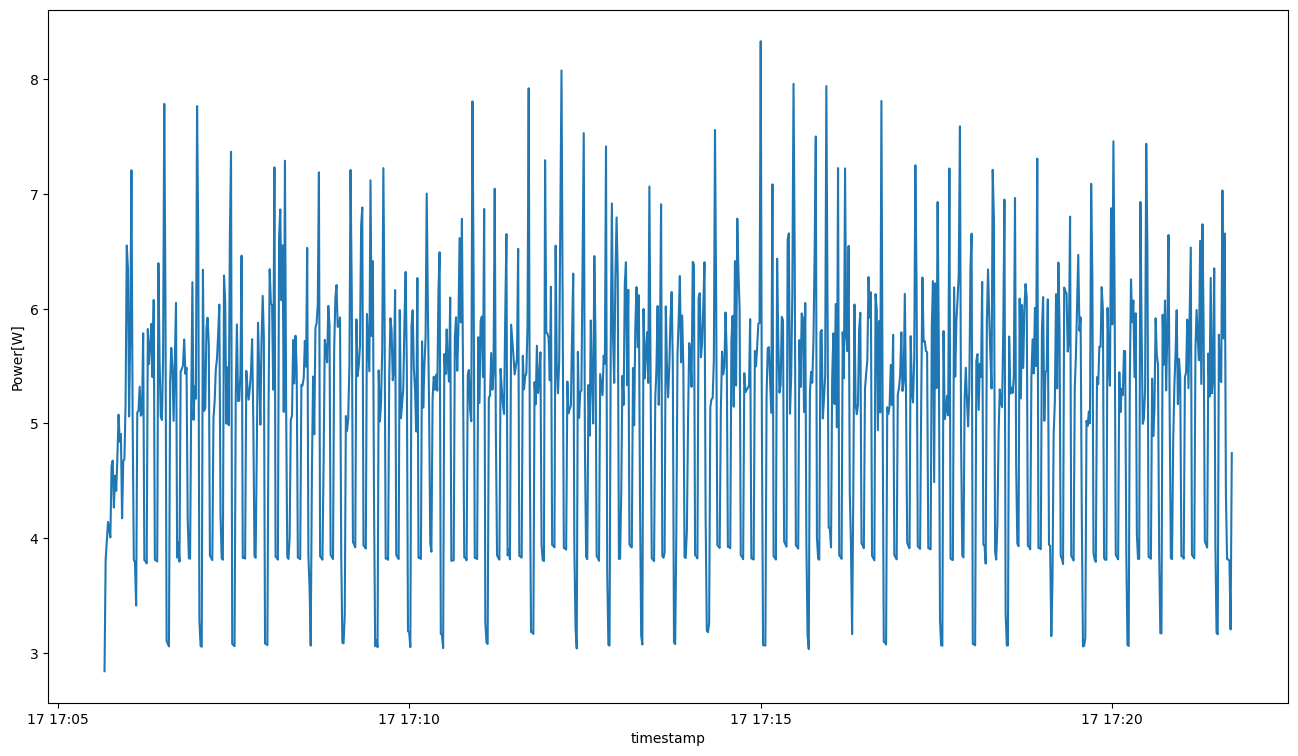

In [56]:
plt.figure(figsize=(16, 9))
sns.lineplot(data=dx21_power.sort_values(by='timestamp'), x="timestamp", y="Power[W]")
plt.show()

In [57]:
dx21_power.describe()

,Time[S],Volt[V],Current[A],Power[W],timestamp,dt_hours,energy_Wh
count,963.000000,963.000000,963.000000,963.000000,963,962.000000,962.000000
mean,481.051506,5.108512,0.996084,5.082774,2026-04-17 17:13:41.006216,0.000278,0.001413
min,0.000000,5.081600,0.556770,2.839500,2026-04-17 17:05:39.967578,0.000269,0.000823
25%,240.500000,5.106800,0.767330,3.914350,2026-04-17 17:09:40.466345,0.000271,0.001090
50%,481.100000,5.108900,1.039610,5.308100,2026-04-17 17:13:41.006946,0.000283,0.001471
75%,721.600000,5.110500,1.139720,5.822300,2026-04-17 17:17:41.542701,0.000283,0.001619
max,962.100000,5.126600,1.633880,8.332700,2026-04-17 17:21:42.073095,0.000285,0.002357
std,278.181740,0.004876,0.215800,1.101655,NaN,0.000006,0.000307


## X2.2

passage_time: 05; interval: 3; window: 2

In [58]:
x22_folder_path = '../infra/reports/batch_x22'

### Predict

In [59]:
from pandas import json_normalize
import json

with open(f'{x22_folder_path}/metrics.json') as f:
    x22_data = json.load(f)

load_model_duration = datetime.fromisoformat(x22_data['load_model_final']) - datetime.fromisoformat(x22_data['load_model_start'])
    
rows = []
for animal, v1 in x22_data['animals'].items():
    row = {
        'pid': x22_data['pid'],
        'load_model_start': datetime.fromisoformat(x22_data['load_model_start']),
        'load_model_final': datetime.fromisoformat(x22_data['load_model_final']),
        'load_model_dur': load_model_duration,
        'animal':animal,
        'first_image_capture_time':datetime.fromisoformat(v1['first_image_capture_time']),
        'last_image_capture_time' :datetime.fromisoformat(v1['last_image_capture_time']),
        'display_time' :datetime.fromisoformat(v1['weight_prediction_final']),
        'total_of_images':v1['total_of_images'],
        'suitable_images':v1['suitable_images'],
    }
    
    for img, v2 in v1['imgs'].items():
        for k, v3 in v2.items():
            row[k] = datetime.fromisoformat(v3)

        rows.append(row)

dx22_metrics_v0 = pd.DataFrame.from_dict(rows)#[['pid','load_model_start','load_model_final','load_model_dur','animal','first_image_capture_time','last_image_capture_time','weight_prediction_start','weight_prediction_final','display_time']]
dx22_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final
0,batch_2026-04-17T17:23:13.606892,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,1,2026-04-17 17:23:20.817550,2026-04-17 17:23:25.051491,2026-04-17 17:23:27.149361,5,2,2026-04-17 17:23:26.053263,2026-04-17 17:23:27.149276
1,batch_2026-04-17T17:23:13.606892,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,2,2026-04-17 17:23:30.149493,2026-04-17 17:23:34.230082,2026-04-17 17:23:36.324334,5,2,2026-04-17 17:23:35.230087,2026-04-17 17:23:36.324259
2,batch_2026-04-17T17:23:13.606892,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,3,2026-04-17 17:23:39.326018,2026-04-17 17:23:43.413946,2026-04-17 17:23:45.510090,5,2,2026-04-17 17:23:44.418656,2026-04-17 17:23:45.510020
3,batch_2026-04-17T17:23:13.606892,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,4,2026-04-17 17:23:48.511756,2026-04-17 17:23:52.564145,2026-04-17 17:23:54.659002,5,2,2026-04-17 17:23:53.564108,2026-04-17 17:23:54.658938
4,batch_2026-04-17T17:23:13.606892,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,5,2026-04-17 17:23:57.660964,2026-04-17 17:24:01.727721,2026-04-17 17:24:03.836864,5,2,2026-04-17 17:24:02.728530,2026-04-17 17:24:03.836799


In [60]:
dx22_metrics_v0['by_animal_lead_time'] = dx22_metrics_v0['display_time'] - dx22_metrics_v0['first_image_capture_time']
dx22_metrics_v0['by_animal_processing_delay'] = dx22_metrics_v0['weight_prediction_final'] - dx22_metrics_v0['weight_prediction_start']
dx22_metrics_v0['by_animal_latency'] = dx22_metrics_v0['display_time'] - dx22_metrics_v0['last_image_capture_time']

dx22_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final,by_animal_lead_time,by_animal_processing_delay,by_animal_latency
0,batch_2026-04-17T17:23:13.606892,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,1,2026-04-17 17:23:20.817550,2026-04-17 17:23:25.051491,2026-04-17 17:23:27.149361,5,2,2026-04-17 17:23:26.053263,2026-04-17 17:23:27.149276,0 days 00:00:06.331811,0 days 00:00:01.096013,0 days 00:00:02.097870
1,batch_2026-04-17T17:23:13.606892,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,2,2026-04-17 17:23:30.149493,2026-04-17 17:23:34.230082,2026-04-17 17:23:36.324334,5,2,2026-04-17 17:23:35.230087,2026-04-17 17:23:36.324259,0 days 00:00:06.174841,0 days 00:00:01.094172,0 days 00:00:02.094252
2,batch_2026-04-17T17:23:13.606892,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,3,2026-04-17 17:23:39.326018,2026-04-17 17:23:43.413946,2026-04-17 17:23:45.510090,5,2,2026-04-17 17:23:44.418656,2026-04-17 17:23:45.510020,0 days 00:00:06.184072,0 days 00:00:01.091364,0 days 00:00:02.096144
3,batch_2026-04-17T17:23:13.606892,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,4,2026-04-17 17:23:48.511756,2026-04-17 17:23:52.564145,2026-04-17 17:23:54.659002,5,2,2026-04-17 17:23:53.564108,2026-04-17 17:23:54.658938,0 days 00:00:06.147246,0 days 00:00:01.094830,0 days 00:00:02.094857
4,batch_2026-04-17T17:23:13.606892,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,5,2026-04-17 17:23:57.660964,2026-04-17 17:24:01.727721,2026-04-17 17:24:03.836864,5,2,2026-04-17 17:24:02.728530,2026-04-17 17:24:03.836799,0 days 00:00:06.175900,0 days 00:00:01.108269,0 days 00:00:02.109143


In [61]:
collect_lead_time = dx22_metrics_v0['display_time'].max() - dx22_metrics_v0['first_image_capture_time'].min()
qtt = len(dx22_metrics_v0['animal'].unique())

dx22_metrics_v0['collect_lead_time'] = collect_lead_time
dx22_metrics_v0['mean_throughput'] = qtt / (collect_lead_time.total_seconds() / 60 / 60) # hour

dx22_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final,by_animal_lead_time,by_animal_processing_delay,by_animal_latency,collect_lead_time,mean_throughput
0,batch_2026-04-17T17:23:13.606892,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,1,2026-04-17 17:23:20.817550,2026-04-17 17:23:25.051491,2026-04-17 17:23:27.149361,5,2,2026-04-17 17:23:26.053263,2026-04-17 17:23:27.149276,0 days 00:00:06.331811,0 days 00:00:01.096013,0 days 00:00:02.097870,0 days 00:15:12.280985,394.615262
1,batch_2026-04-17T17:23:13.606892,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,2,2026-04-17 17:23:30.149493,2026-04-17 17:23:34.230082,2026-04-17 17:23:36.324334,5,2,2026-04-17 17:23:35.230087,2026-04-17 17:23:36.324259,0 days 00:00:06.174841,0 days 00:00:01.094172,0 days 00:00:02.094252,0 days 00:15:12.280985,394.615262
2,batch_2026-04-17T17:23:13.606892,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,3,2026-04-17 17:23:39.326018,2026-04-17 17:23:43.413946,2026-04-17 17:23:45.510090,5,2,2026-04-17 17:23:44.418656,2026-04-17 17:23:45.510020,0 days 00:00:06.184072,0 days 00:00:01.091364,0 days 00:00:02.096144,0 days 00:15:12.280985,394.615262
3,batch_2026-04-17T17:23:13.606892,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,4,2026-04-17 17:23:48.511756,2026-04-17 17:23:52.564145,2026-04-17 17:23:54.659002,5,2,2026-04-17 17:23:53.564108,2026-04-17 17:23:54.658938,0 days 00:00:06.147246,0 days 00:00:01.094830,0 days 00:00:02.094857,0 days 00:15:12.280985,394.615262
4,batch_2026-04-17T17:23:13.606892,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,5,2026-04-17 17:23:57.660964,2026-04-17 17:24:01.727721,2026-04-17 17:24:03.836864,5,2,2026-04-17 17:24:02.728530,2026-04-17 17:24:03.836799,0 days 00:00:06.175900,0 days 00:00:01.108269,0 days 00:00:02.109143,0 days 00:15:12.280985,394.615262


In [62]:
dx22_metrics_v0.describe()

,load_model_start,load_model_final,load_model_dur,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final,by_animal_lead_time,by_animal_processing_delay,by_animal_latency,collect_lead_time,mean_throughput
count,100,100,100,100,100,100,100.0,100.0,100,100,100,100,100,100,1.000000e+02
mean,2026-04-17 17:23:13.607625,2026-04-17 17:23:20.817436,0 days 00:00:07.209811,2026-04-17 17:30:54.077514,2026-04-17 17:30:58.134957,2026-04-17 17:31:00.228556,5.0,2.0,2026-04-17 17:30:59.134332,2026-04-17 17:31:00.228488,0 days 00:00:06.151042,0 days 00:00:01.094155,0 days 00:00:02.093599,0 days 00:15:12.280985,3.946153e+02
min,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,2026-04-17 17:23:20.817550,2026-04-17 17:23:25.051491,2026-04-17 17:23:27.149361,5.0,2.0,2026-04-17 17:23:26.053263,2026-04-17 17:23:27.149276,0 days 00:00:06.122840,0 days 00:00:01.083887,0 days 00:00:02.079102,0 days 00:15:12.280985,3.946153e+02
25%,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,2026-04-17 17:27:07.542742,2026-04-17 17:27:11.604179,2026-04-17 17:27:13.692103,5.0,2.0,2026-04-17 17:27:12.602005,2026-04-17 17:27:13.692037,0 days 00:00:06.138786,0 days 00:00:01.090165,0 days 00:00:02.088810,0 days 00:15:12.280985,3.946153e+02
50%,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,2026-04-17 17:30:54.142326,2026-04-17 17:30:58.213133,2026-04-17 17:31:00.300144,5.0,2.0,2026-04-17 17:30:59.213463,2026-04-17 17:31:00.300075,0 days 00:00:06.146558,0 days 00:00:01.092441,0 days 00:00:02.092301,0 days 00:15:12.280985,3.946153e+02
75%,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,2026-04-17 17:34:40.540885,2026-04-17 17:34:44.598086,2026-04-17 17:34:46.687670,5.0,2.0,2026-04-17 17:34:45.598684,2026-04-17 17:34:46.687604,0 days 00:00:06.158405,0 days 00:00:01.098142,0 days 00:00:02.098106,0 days 00:15:12.280985,3.946153e+02
max,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,2026-04-17 17:38:26.969342,2026-04-17 17:38:31.009891,2026-04-17 17:38:33.098535,5.0,2.0,2026-04-17 17:38:32.006589,2026-04-17 17:38:33.098466,0 days 00:00:06.331811,0 days 00:00:01.114705,0 days 00:00:02.115076,0 days 00:15:12.280985,3.946153e+02
std,NaN,NaN,0 days 00:00:00,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0 days 00:00:00.023086,0 days 00:00:00.006114,0 days 00:00:00.006548,0 days 00:00:00,1.142596e-13


In [63]:
dx22_metrics_v0['by_animal_processing_delay'].sum()

Timedelta('0 days 00:01:49.415564')

In [64]:
total_of_imgs = dx22_metrics_v0['total_of_images'].sum()
total_time = pd.to_timedelta(dx22_metrics_v0['collect_lead_time'].unique()[0])

print(f'Imgs: {total_of_imgs} - Time: {total_time} => FPS:{total_of_imgs / total_time.total_seconds()}')

Imgs: 500 - Time: 0 days 00:15:12.280985 => FPS:0.5480767529096312


### CPU

In [65]:
dx22_cpu = pd.read_csv(f'{x22_folder_path}/cpu.csv')

dx22_cpu['timestamp'] = dx22_cpu['timestamp'].apply(lambda x: datetime.fromisoformat(x))
dx22_cpu['cpu_mean']  = dx22_cpu[['cpu_core_0', 'cpu_core_1', 'cpu_core_2', 'cpu_core_3']].mean(axis=1)

dx22_cpu.head()

,timestamp,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
0,2026-04-17 17:23:14.609670,3.0,3.0,3.0,94.9,25.975
1,2026-04-17 17:23:15.620245,12.6,37.6,34.7,45.5,32.600
2,2026-04-17 17:23:16.646788,0.0,0.0,0.0,99.0,24.750
3,2026-04-17 17:23:17.647689,0.0,0.0,0.0,61.4,15.350
4,2026-04-17 17:23:18.648134,0.0,0.0,0.0,3.0,0.750


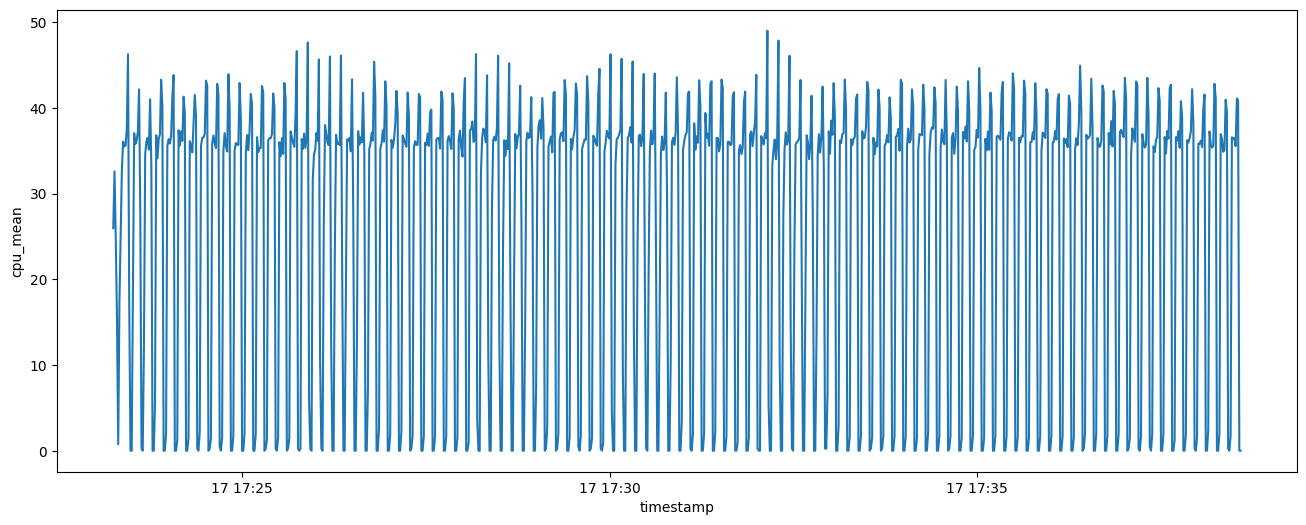

In [66]:
plt.figure(figsize=(16, 6))
sns.lineplot(data=dx22_cpu.sort_values(by='timestamp'), x="timestamp", y="cpu_mean")
plt.show()

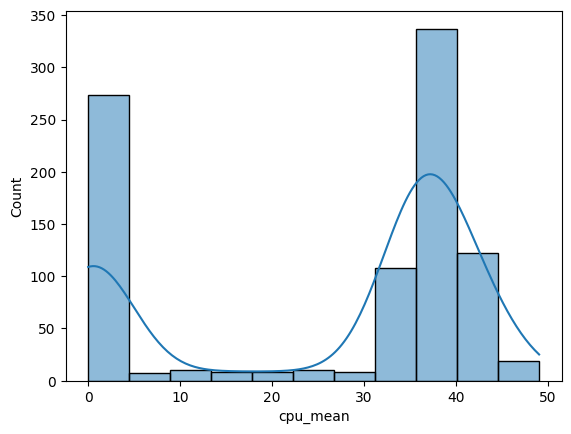

In [67]:
sns.histplot(data=dx22_cpu, x="cpu_mean", kde=True)
plt.show()

In [68]:
dx22_cpu.describe()

,timestamp,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
count,911,911.000000,911.000000,911.000000,911.000000,911.000000
mean,2026-04-17 17:30:54.318860,24.303293,27.089352,26.418441,24.326015,25.534276
min,2026-04-17 17:23:14.609670,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2026-04-17 17:27:04.380313,0.000000,0.000000,0.000000,0.000000,1.725000
50%,2026-04-17 17:30:53.840343,20.800000,25.500000,25.000000,21.600000,35.800000
75%,2026-04-17 17:34:43.955204,37.700000,43.600000,42.400000,38.100000,37.150000
max,2026-04-17 17:38:35.168794,91.900000,91.000000,92.100000,100.000000,49.025000
std,NaN,21.778822,23.478179,22.739804,21.588562,17.307429


### RAM

In [69]:
dx22_ram = pd.read_csv(f'{x22_folder_path}/mem.csv')
dx22_ram['timestamp'] = dx22_ram['timestamp'].apply(lambda x: datetime.fromisoformat(x))
dx22_ram.head()

,timestamp,total,available,used,percent,free,active,inactive,buffers,cached
0,2026-04-17 17:23:13.607824,17002643456,16381460480,621182976,3.7,15799484416,719716352,184123392,38420480,661766144
1,2026-04-17 17:23:14.609496,17002643456,16340500480,662142976,3.9,15755640832,752795648,185270272,38420480,664305664
2,2026-04-17 17:23:15.625407,17002643456,16269017088,733626368,4.3,15684157440,824918016,185270272,38420480,664305664
3,2026-04-17 17:23:16.636485,17002643456,16231563264,771080192,4.5,15646572544,850165760,185270272,38420480,664436736
4,2026-04-17 17:23:17.636946,17002643456,16090972160,911671296,5.4,15468019712,982319104,223232000,38420480,702726144


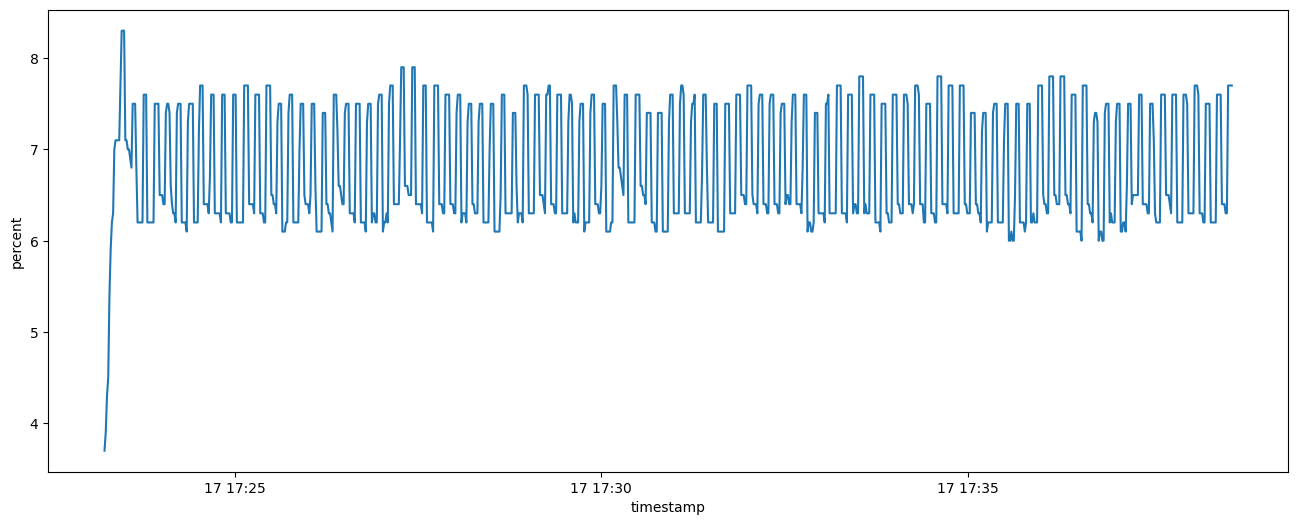

In [70]:
plt.figure(figsize=(16, 6))
sns.lineplot(data=dx22_ram.sort_values(by='timestamp'), x="timestamp", y="percent")
plt.show()

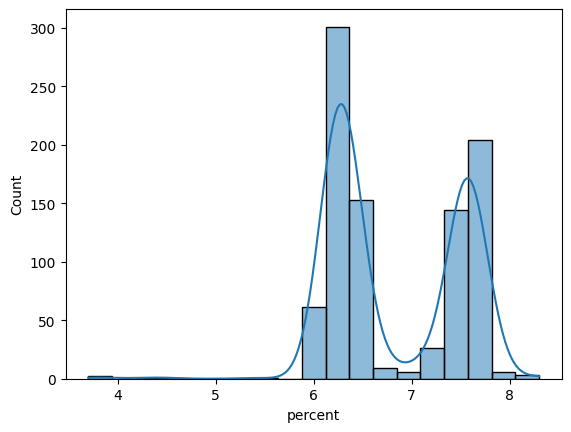

In [71]:
sns.histplot(data=dx22_ram, x="percent", kde=True)
plt.show()

In [72]:
dx22_ram.describe()

,timestamp,total,available,used,percent,free,active,inactive,buffers,cached
count,918,9.180000e+02,9.180000e+02,9.180000e+02,918.000000,9.180000e+02,9.180000e+02,9.180000e+02,9.180000e+02,9.180000e+02
mean,2026-04-17 17:30:54.325897,1.700264e+10,1.584317e+10,1.159473e+09,6.817974,1.509685e+10,1.292058e+09,3.427112e+08,3.851311e+07,8.257464e+08
min,2026-04-17 17:23:13.607824,1.700264e+10,1.559039e+10,6.211830e+08,3.700000,1.484328e+10,7.197164e+08,1.841234e+08,3.842048e+07,6.617661e+08
25%,2026-04-17 17:27:03.688167,1.700264e+10,1.572081e+10,1.063469e+09,6.300000,1.497362e+10,1.198686e+09,3.435233e+08,3.846963e+07,8.266220e+08
50%,2026-04-17 17:30:54.050247,1.700264e+10,1.590872e+10,1.093919e+09,6.400000,1.516129e+10,1.201848e+09,3.435233e+08,3.846963e+07,8.266220e+08
75%,2026-04-17 17:34:45.203597,1.700264e+10,1.593917e+10,1.281835e+09,7.500000,1.519201e+10,1.431421e+09,3.435397e+08,3.848602e+07,8.266220e+08
max,2026-04-17 17:38:36.161496,1.700264e+10,1.638146e+10,1.412252e+09,8.300000,1.579948e+10,1.437270e+09,3.439821e+08,3.892838e+07,8.269332e+08
std,NaN,0.000000e+00,1.133172e+08,1.133172e+08,0.666567,1.171029e+08,1.184573e+08,1.121407e+07,1.284345e+05,1.153321e+07


### Power

In [73]:
dx22_power = pd.read_csv(f'{x22_folder_path}/power.csv')
dx22_power['timestamp'] = dx22_power['Datetime'].apply(lambda x: datetime.fromisoformat(x))
dx22_power.head()

,Datetime,Time[S],Volt[V],Current[A],Power[W],timestamp
0,2026-04-17T17:23:03.372126,0.0,5.1099,0.76189,3.8856,2026-04-17 17:23:03.372126
1,2026-04-17T17:23:04.390572,1.0,5.1045,0.86995,4.4367,2026-04-17 17:23:04.390572
2,2026-04-17T17:23:05.367513,2.0,5.1097,0.79081,4.0331,2026-04-17 17:23:05.367513
3,2026-04-17T17:23:06.387981,3.0,5.1093,0.87220,4.4482,2026-04-17 17:23:06.387981
4,2026-04-17T17:23:07.363427,4.0,5.1089,0.79309,4.0447,2026-04-17 17:23:07.363427


In [74]:
dx22_power = dx22_power.sort_values('timestamp')

# Time difference in hours
dx22_power['dt_hours'] = dx22_power['timestamp'].diff().dt.total_seconds() / 3600

# Energy (Wh)
dx22_power['energy_Wh'] = dx22_power['Power[W]'] * dx22_power['dt_hours']

# Total energy
total_energy_Wh = dx22_power['energy_Wh'].sum()

print("Total energy (Wh):", total_energy_Wh)
print("Total energy (kWh):", total_energy_Wh / 1000)

Total energy (Wh): 1.2854588055465
Total energy (kWh): 0.0012854588055465


In [75]:
dx22_power.describe()

,Time[S],Volt[V],Current[A],Power[W],timestamp,dt_hours,energy_Wh
count,936.000000,936.000000,936.000000,936.000000,936,935.000000,935.000000
mean,467.550962,5.109087,0.969477,4.947751,2026-04-17 17:30:50.921378,0.000278,0.001375
min,0.000000,5.091400,0.594620,3.038200,2026-04-17 17:23:03.372126,0.000269,0.000820
25%,233.750000,5.107600,0.747018,3.811875,2026-04-17 17:26:57.157292,0.000271,0.001079
50%,467.600000,5.109500,1.019705,5.205850,2026-04-17 17:30:50.921912,0.000283,0.001449
75%,701.350000,5.110800,1.116733,5.700350,2026-04-17 17:34:44.696437,0.000283,0.001583
max,935.100000,5.122800,1.504110,7.670900,2026-04-17 17:38:38.449525,0.000285,0.002176
std,270.387535,0.004418,0.210624,1.075021,NaN,0.000006,0.000300


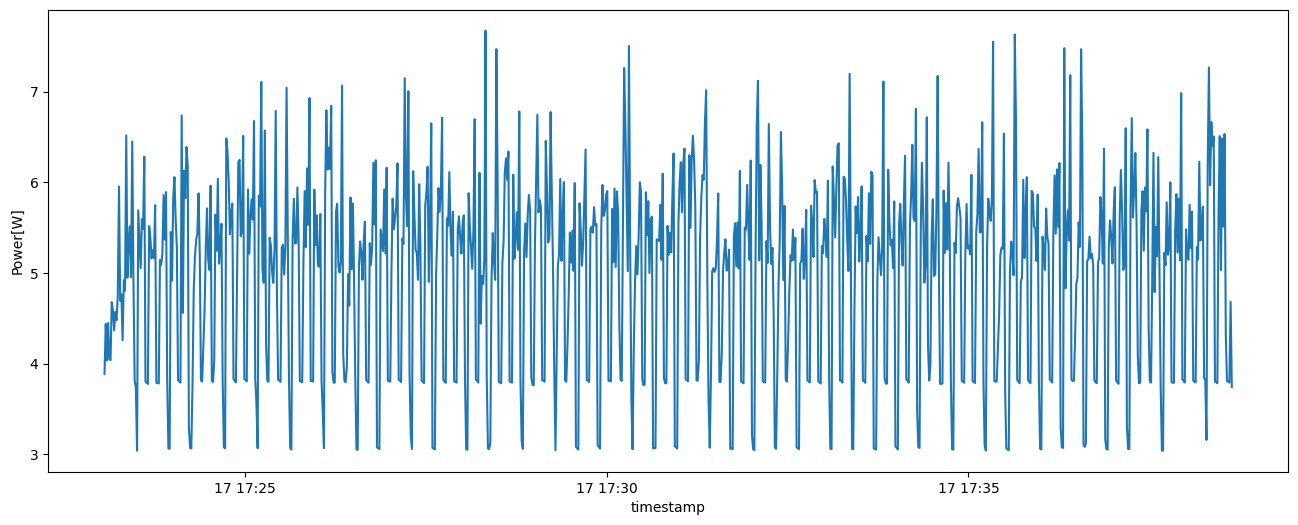

In [76]:
plt.figure(figsize=(16, 6))
sns.lineplot(data=dx22_power.sort_values(by='timestamp'), x="timestamp", y="Power[W]")
plt.show()

## X2.3

passage_time: 05; interval: 3; window: 1

In [77]:
x23_folder_path = '../infra/reports/batch_x23'

### Predict

In [78]:
from pandas import json_normalize
import json

with open(f'{x23_folder_path}/metrics.json') as f:
    x23_data = json.load(f)

load_model_duration = datetime.fromisoformat(x23_data['load_model_final']) - datetime.fromisoformat(x23_data['load_model_start'])
    
rows = []
for animal, v1 in x23_data['animals'].items():
    row = {
        'pid': x23_data['pid'],
        'load_model_start': datetime.fromisoformat(x23_data['load_model_start']),
        'load_model_final': datetime.fromisoformat(x23_data['load_model_final']),
        'load_model_dur': load_model_duration,
        'animal':animal,
        'first_image_capture_time':datetime.fromisoformat(v1['first_image_capture_time']),
        'last_image_capture_time' :datetime.fromisoformat(v1['last_image_capture_time']),
        'display_time' :datetime.fromisoformat(v1['weight_prediction_final']),
        'total_of_images':v1['total_of_images'],
        'suitable_images':v1['suitable_images'],       
    }
    
    for img, v2 in v1['imgs'].items():
        for k, v3 in v2.items():
            row[k] = datetime.fromisoformat(v3)

        rows.append(row)

dx23_metrics_v0 = pd.DataFrame.from_dict(rows)#[['pid','load_model_start','load_model_final','load_model_dur','animal','first_image_capture_time','last_image_capture_time','weight_prediction_start','weight_prediction_final','display_time']]
dx23_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final
0,batch_2026-04-17T17:40:07.128032,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,1,2026-04-17 17:40:14.096217,2026-04-17 17:40:18.189555,2026-04-17 17:40:19.991632,5,1,2026-04-17 17:40:19.155883,2026-04-17 17:40:19.991552
1,batch_2026-04-17T17:40:07.128032,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,2,2026-04-17 17:40:22.991742,2026-04-17 17:40:27.895202,2026-04-17 17:40:29.943751,6,2,2026-04-17 17:40:28.866081,2026-04-17 17:40:29.943682
2,batch_2026-04-17T17:40:07.128032,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,3,2026-04-17 17:40:32.944677,2026-04-17 17:40:37.880968,2026-04-17 17:40:39.704239,6,1,2026-04-17 17:40:38.869534,2026-04-17 17:40:39.704174
3,batch_2026-04-17T17:40:07.128032,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,4,2026-04-17 17:40:42.705932,2026-04-17 17:40:47.622870,2026-04-17 17:40:49.681409,6,2,2026-04-17 17:40:48.603484,2026-04-17 17:40:49.681346
4,batch_2026-04-17T17:40:07.128032,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,5,2026-04-17 17:40:52.683097,2026-04-17 17:40:57.636133,2026-04-17 17:40:59.681285,6,2,2026-04-17 17:40:58.604857,2026-04-17 17:40:59.681222


In [79]:
dx23_metrics_v0['by_animal_lead_time'] = dx23_metrics_v0['display_time'] - dx23_metrics_v0['first_image_capture_time']
dx23_metrics_v0['by_animal_processing_delay'] = dx23_metrics_v0['weight_prediction_final'] - dx23_metrics_v0['weight_prediction_start']
dx23_metrics_v0['by_animal_latency'] = dx23_metrics_v0['display_time'] - dx23_metrics_v0['last_image_capture_time']

dx23_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final,by_animal_lead_time,by_animal_processing_delay,by_animal_latency
0,batch_2026-04-17T17:40:07.128032,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,1,2026-04-17 17:40:14.096217,2026-04-17 17:40:18.189555,2026-04-17 17:40:19.991632,5,1,2026-04-17 17:40:19.155883,2026-04-17 17:40:19.991552,0 days 00:00:05.895415,0 days 00:00:00.835669,0 days 00:00:01.802077
1,batch_2026-04-17T17:40:07.128032,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,2,2026-04-17 17:40:22.991742,2026-04-17 17:40:27.895202,2026-04-17 17:40:29.943751,6,2,2026-04-17 17:40:28.866081,2026-04-17 17:40:29.943682,0 days 00:00:06.952009,0 days 00:00:01.077601,0 days 00:00:02.048549
2,batch_2026-04-17T17:40:07.128032,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,3,2026-04-17 17:40:32.944677,2026-04-17 17:40:37.880968,2026-04-17 17:40:39.704239,6,1,2026-04-17 17:40:38.869534,2026-04-17 17:40:39.704174,0 days 00:00:06.759562,0 days 00:00:00.834640,0 days 00:00:01.823271
3,batch_2026-04-17T17:40:07.128032,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,4,2026-04-17 17:40:42.705932,2026-04-17 17:40:47.622870,2026-04-17 17:40:49.681409,6,2,2026-04-17 17:40:48.603484,2026-04-17 17:40:49.681346,0 days 00:00:06.975477,0 days 00:00:01.077862,0 days 00:00:02.058539
4,batch_2026-04-17T17:40:07.128032,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,5,2026-04-17 17:40:52.683097,2026-04-17 17:40:57.636133,2026-04-17 17:40:59.681285,6,2,2026-04-17 17:40:58.604857,2026-04-17 17:40:59.681222,0 days 00:00:06.998188,0 days 00:00:01.076365,0 days 00:00:02.045152


In [80]:
collect_lead_time = dx23_metrics_v0['display_time'].max() - dx23_metrics_v0['first_image_capture_time'].min()
qtt = len(dx23_metrics_v0['animal'].unique())

dx23_metrics_v0['collect_lead_time'] = collect_lead_time
dx23_metrics_v0['mean_throughput'] = qtt / (collect_lead_time.total_seconds() / 60 / 60) # hour

dx23_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final,by_animal_lead_time,by_animal_processing_delay,by_animal_latency,collect_lead_time,mean_throughput
0,batch_2026-04-17T17:40:07.128032,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,1,2026-04-17 17:40:14.096217,2026-04-17 17:40:18.189555,2026-04-17 17:40:19.991632,5,1,2026-04-17 17:40:19.155883,2026-04-17 17:40:19.991552,0 days 00:00:05.895415,0 days 00:00:00.835669,0 days 00:00:01.802077,0 days 00:16:28.097418,364.336546
1,batch_2026-04-17T17:40:07.128032,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,2,2026-04-17 17:40:22.991742,2026-04-17 17:40:27.895202,2026-04-17 17:40:29.943751,6,2,2026-04-17 17:40:28.866081,2026-04-17 17:40:29.943682,0 days 00:00:06.952009,0 days 00:00:01.077601,0 days 00:00:02.048549,0 days 00:16:28.097418,364.336546
2,batch_2026-04-17T17:40:07.128032,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,3,2026-04-17 17:40:32.944677,2026-04-17 17:40:37.880968,2026-04-17 17:40:39.704239,6,1,2026-04-17 17:40:38.869534,2026-04-17 17:40:39.704174,0 days 00:00:06.759562,0 days 00:00:00.834640,0 days 00:00:01.823271,0 days 00:16:28.097418,364.336546
3,batch_2026-04-17T17:40:07.128032,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,4,2026-04-17 17:40:42.705932,2026-04-17 17:40:47.622870,2026-04-17 17:40:49.681409,6,2,2026-04-17 17:40:48.603484,2026-04-17 17:40:49.681346,0 days 00:00:06.975477,0 days 00:00:01.077862,0 days 00:00:02.058539,0 days 00:16:28.097418,364.336546
4,batch_2026-04-17T17:40:07.128032,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,5,2026-04-17 17:40:52.683097,2026-04-17 17:40:57.636133,2026-04-17 17:40:59.681285,6,2,2026-04-17 17:40:58.604857,2026-04-17 17:40:59.681222,0 days 00:00:06.998188,0 days 00:00:01.076365,0 days 00:00:02.045152,0 days 00:16:28.097418,364.336546


In [81]:
dx23_metrics_v0.describe()

,load_model_start,load_model_final,load_model_dur,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final,by_animal_lead_time,by_animal_processing_delay,by_animal_latency,collect_lead_time,mean_throughput
count,100,100,100,100,100,100,100.00,100.000000,100,100,100,100,100,100,1.000000e+02
mean,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,2026-04-17 17:48:24.302942,2026-04-17 17:48:29.216736,2026-04-17 17:48:31.212248,5.99,1.760000,2026-04-17 17:48:30.193143,2026-04-17 17:48:31.212183,0 days 00:00:06.909305,0 days 00:00:01.019039,0 days 00:00:01.995511,0 days 00:16:28.097418,3.643365e+02
min,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,2026-04-17 17:40:14.096217,2026-04-17 17:40:18.189555,2026-04-17 17:40:19.991632,5.00,1.000000,2026-04-17 17:40:19.155883,2026-04-17 17:40:19.991552,0 days 00:00:05.895415,0 days 00:00:00.831709,0 days 00:00:01.802077,0 days 00:16:28.097418,3.643365e+02
25%,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,2026-04-17 17:44:18.657442,2026-04-17 17:44:23.578121,2026-04-17 17:44:25.632422,6.00,2.000000,2026-04-17 17:44:24.551680,2026-04-17 17:44:25.632358,0 days 00:00:06.940671,0 days 00:00:01.065616,0 days 00:00:02.036826,0 days 00:16:28.097418,3.643365e+02
50%,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,2026-04-17 17:48:24.165287,2026-04-17 17:48:29.080115,2026-04-17 17:48:31.013439,6.00,2.000000,2026-04-17 17:48:30.059284,2026-04-17 17:48:31.013375,0 days 00:00:06.960227,0 days 00:00:01.072188,0 days 00:00:02.047566,0 days 00:16:28.097418,3.643365e+02
75%,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,2026-04-17 17:52:30.025344,2026-04-17 17:52:34.931259,2026-04-17 17:52:36.987154,6.00,2.000000,2026-04-17 17:52:35.907694,2026-04-17 17:52:36.987087,0 days 00:00:06.976052,0 days 00:00:01.081017,0 days 00:00:02.053530,0 days 00:16:28.097418,3.643365e+02
max,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,2026-04-17 17:56:35.194746,2026-04-17 17:56:40.139886,2026-04-17 17:56:42.193635,6.00,2.000000,2026-04-17 17:56:41.109587,2026-04-17 17:56:42.193574,0 days 00:00:07.013703,0 days 00:00:01.097816,0 days 00:00:02.088859,0 days 00:16:28.097418,3.643365e+02
std,NaN,NaN,0 days 00:00:00,NaN,NaN,NaN,0.10,0.429235,NaN,NaN,0 days 00:00:00.139444,0 days 00:00:00.104033,0 days 00:00:00.100743,0 days 00:00:00,5.712979e-14


In [82]:
dx23_metrics_v0['by_animal_processing_delay'].sum()

Timedelta('0 days 00:01:41.903925')

In [83]:
total_of_imgs = dx23_metrics_v0['total_of_images'].sum()
total_time = pd.to_timedelta(dx23_metrics_v0['collect_lead_time'].unique()[0])

print(f'Imgs: {total_of_imgs} - Time: {total_time} => FPS:{total_of_imgs / total_time.total_seconds()}')

Imgs: 599 - Time: 0 days 00:16:28.097418 => FPS:0.606215530056167


### CPU

In [84]:
dx23_cpu = pd.read_csv(f'{x23_folder_path}/cpu.csv')

dx23_cpu['timestamp'] = dx23_cpu['timestamp'].apply(lambda x: datetime.fromisoformat(x))
dx23_cpu['cpu_mean']  = dx23_cpu[['cpu_core_0', 'cpu_core_1', 'cpu_core_2', 'cpu_core_3']].mean(axis=1)

dx23_cpu.head()

,timestamp,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
0,2026-04-17 17:40:08.129732,1.0,3.0,95.0,2.0,25.250
1,2026-04-17 17:40:09.145478,11.0,40.8,63.0,10.0,31.200
2,2026-04-17 17:40:10.319013,0.9,81.2,17.5,0.9,25.125
3,2026-04-17 17:40:11.319525,1.0,0.0,37.6,0.0,9.650
4,2026-04-17 17:40:12.319928,0.0,0.0,4.0,1.0,1.250


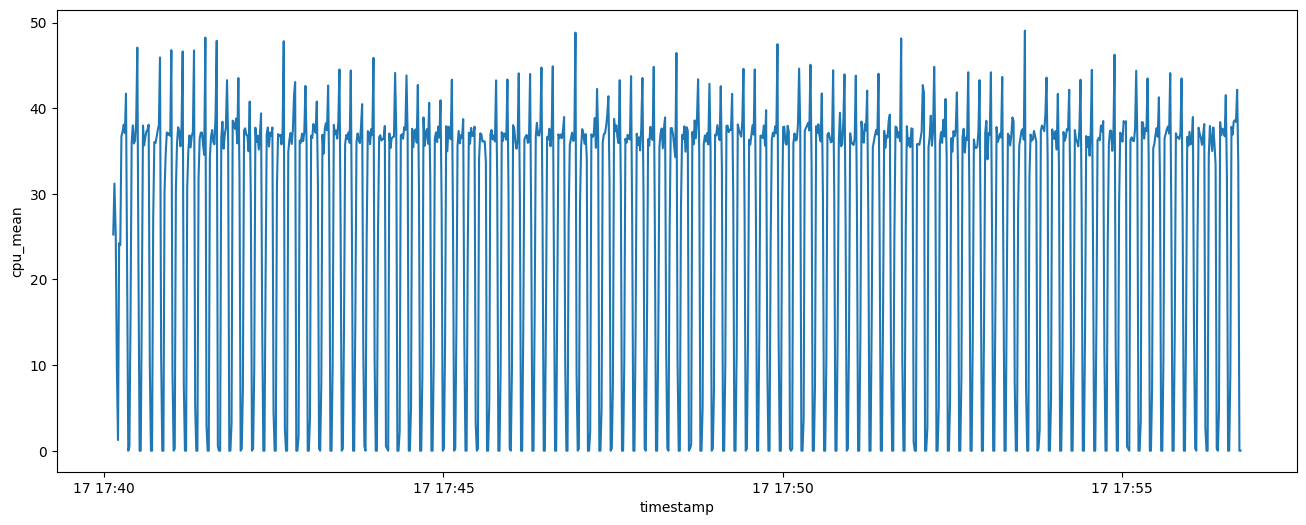

In [85]:
plt.figure(figsize=(16, 6))
sns.lineplot(data=dx23_cpu.sort_values(by='timestamp'), x="timestamp", y="cpu_mean")
plt.show()

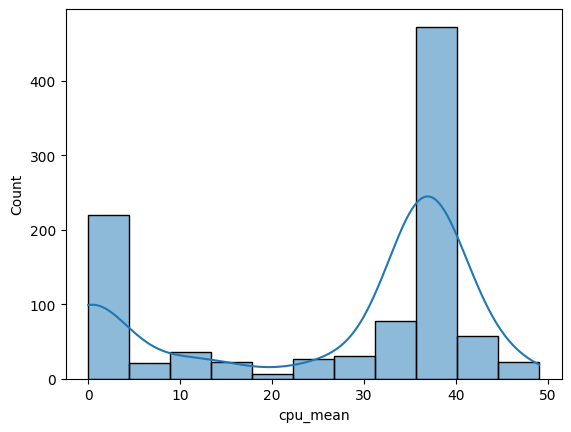

In [86]:
sns.histplot(data=dx23_cpu, x="cpu_mean", kde=True)
plt.show()

In [87]:
dx23_cpu.describe()

,timestamp,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
count,994,994.000000,994.000000,994.000000,994.000000,994.000000
mean,2026-04-17 17:48:26.428363,23.690040,28.871932,29.372535,24.061066,26.498893
min,2026-04-17 17:40:08.129732,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2026-04-17 17:44:17.487582,5.100000,6.100000,6.000000,6.025000,9.743750
50%,2026-04-17 17:48:26.372744,20.900000,26.250000,24.600000,22.000000,36.087500
75%,2026-04-17 17:52:35.496268,34.700000,44.600000,45.875000,35.375000,37.300000
max,2026-04-17 17:56:44.447713,90.000000,91.900000,97.000000,88.000000,49.050000
std,NaN,19.355075,23.076808,24.281167,19.351144,16.035689


### RAM

In [88]:
dx23_ram = pd.read_csv(f'{x23_folder_path}/mem.csv')
dx23_ram['timestamp'] = dx23_ram['timestamp'].apply(lambda x: datetime.fromisoformat(x))
dx23_ram.head()

,timestamp,total,available,used,percent,free,active,inactive,buffers,cached
0,2026-04-17 17:40:07.128923,17002643456,16404578304,598065152,3.5,15822569472,720044032,184516608,38420480,661749760
1,2026-04-17 17:40:08.129821,17002643456,16333815808,668827648,3.9,15748857856,756531200,185319424,38436864,664272896
2,2026-04-17 17:40:09.145592,17002643456,16282173440,720470016,4.2,15697215488,824082432,185319424,38436864,664272896
3,2026-04-17 17:40:10.166128,17002643456,16220372992,782270464,4.6,15635283968,862765056,185319424,38436864,664403968
4,2026-04-17 17:40:11.166486,17002643456,16079405056,923238400,5.4,15447244800,991363072,232390656,38436864,711868416


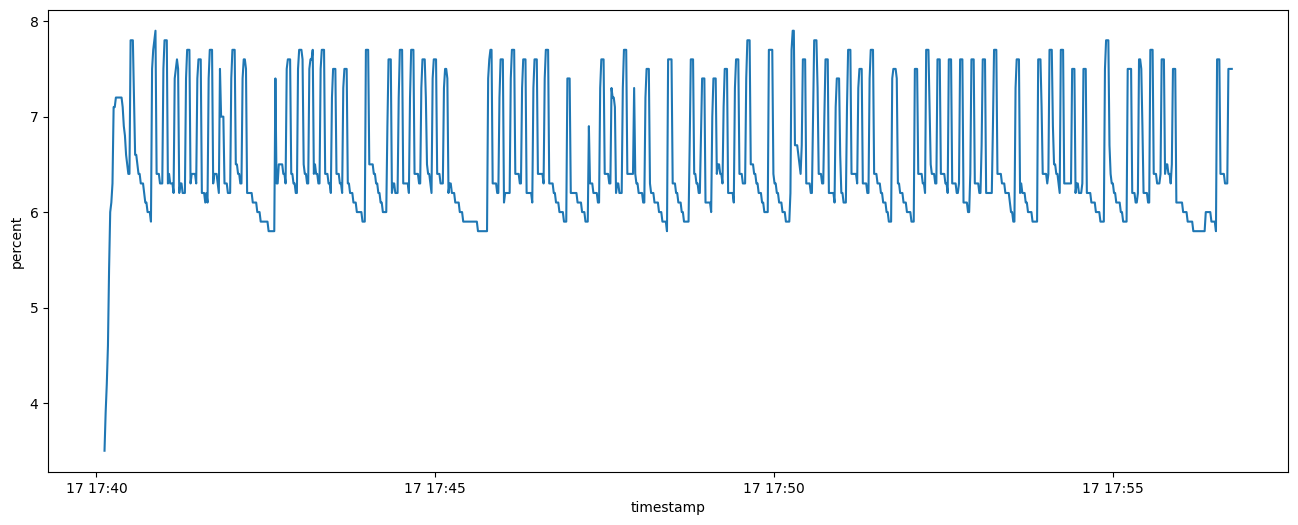

In [89]:
plt.figure(figsize=(16, 6))
sns.lineplot(data=dx23_ram.sort_values(by='timestamp'), x="timestamp", y="percent")
plt.show()

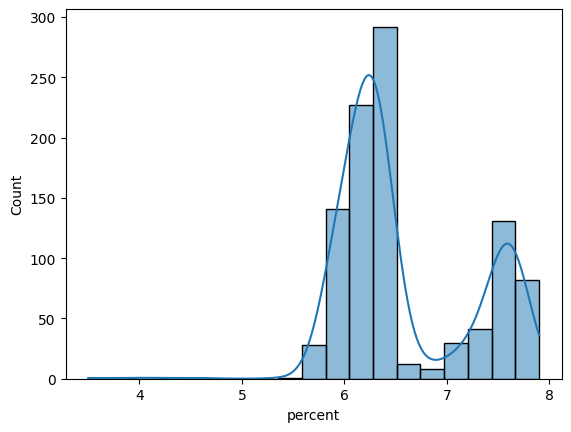

In [90]:
sns.histplot(data=dx23_ram, x="percent", kde=True)
plt.show()

In [91]:
dx23_ram.describe()

,timestamp,total,available,used,percent,free,active,inactive,buffers,cached
count,997,9.970000e+02,9.970000e+02,9.970000e+02,997.00000,9.970000e+02,9.970000e+02,9.970000e+02,9.970000e+02,9.970000e+02
mean,2026-04-17 17:48:26.247930,1.700264e+10,1.588490e+10,1.117741e+09,6.57342,1.513834e+10,1.261533e+09,3.428880e+08,3.856470e+07,8.258285e+08
min,2026-04-17 17:40:07.128923,1.700264e+10,1.565575e+10,5.980652e+08,3.50000,1.490849e+10,7.200440e+08,1.845166e+08,3.842048e+07,6.617498e+08
25%,2026-04-17 17:44:16.638504,1.700264e+10,1.576393e+10,1.043513e+09,6.10000,1.501664e+10,1.202749e+09,3.435889e+08,3.850240e+07,8.266056e+08
50%,2026-04-17 17:48:26.235852,1.700264e+10,1.592964e+10,1.073005e+09,6.30000,1.518233e+10,1.203716e+09,3.436052e+08,3.851878e+07,8.266056e+08
75%,2026-04-17 17:52:35.807356,1.700264e+10,1.595913e+10,1.238712e+09,7.30000,1.521182e+10,1.388642e+09,3.436052e+08,3.851878e+07,8.266056e+08
max,2026-04-17 17:56:45.407786,1.700264e+10,1.640458e+10,1.346896e+09,7.90000,1.582257e+10,1.437745e+09,3.440476e+08,3.896115e+07,8.268841e+08
std,NaN,0.000000e+00,1.109866e+08,1.109866e+08,0.65443,1.141987e+08,1.039854e+08,1.063222e+07,1.534324e+05,1.093728e+07


### Power

In [92]:
dx23_power = pd.read_csv(f'{x23_folder_path}/power.csv')
dx23_power['timestamp'] = dx23_power['Datetime'].apply(lambda x: datetime.fromisoformat(x))
dx23_power.head()

,Datetime,Time[S],Volt[V],Current[A],Power[W],timestamp
0,2026-04-17T17:39:56.343834,0.0,5.1097,0.71063,3.6242,2026-04-17 17:39:56.343834
1,2026-04-17T17:39:57.315169,1.0,5.1097,0.71011,3.6215,2026-04-17 17:39:57.315169
2,2026-04-17T17:39:58.331580,2.0,5.1100,0.82029,4.1916,2026-04-17 17:39:58.331580
3,2026-04-17T17:39:59.347140,3.0,5.1098,0.79178,4.0380,2026-04-17 17:39:59.347140
4,2026-04-17T17:40:00.317420,4.0,5.1098,0.86316,4.4021,2026-04-17 17:40:00.317420


In [93]:
dx23_power = dx23_power.sort_values('timestamp')

# Time difference in hours
dx23_power['dt_hours'] = dx23_power['timestamp'].diff().dt.total_seconds() / 3600

# Energy (Wh)
dx23_power['energy_Wh'] = dx23_power['Power[W]'] * dx23_power['dt_hours']

# Total energy
total_energy_Wh = dx23_power['energy_Wh'].sum()

print("Total energy (Wh):", total_energy_Wh)
print("Total energy (kWh):", total_energy_Wh / 1000)

Total energy (Wh): 1.4217573599010276
Total energy (kWh): 0.0014217573599010277


In [94]:
dx23_power.describe()

,Time[S],Volt[V],Current[A],Power[W],timestamp,dt_hours,energy_Wh
count,1015.000000,1015.000000,1015.000000,1015.000000,1015,1014.000000,1014.000000
mean,507.057537,5.109641,0.988373,5.045314,2026-04-17 17:48:23.385509,0.000278,0.001402
min,0.000000,5.092200,0.599710,3.064500,2026-04-17 17:39:56.343834,0.000269,0.000827
25%,253.500000,5.108450,0.752070,3.841350,2026-04-17 17:44:09.853000,0.000271,0.001085
50%,507.100000,5.110000,1.024830,5.231200,2026-04-17 17:48:23.378066,0.000283,0.001461
75%,760.600000,5.111300,1.125370,5.748000,2026-04-17 17:52:36.907037,0.000283,0.001586
max,1014.100000,5.126100,1.635720,8.342100,2026-04-17 17:56:50.458826,0.000285,0.002261
std,293.191903,0.004281,0.188822,0.963742,NaN,0.000006,0.000270


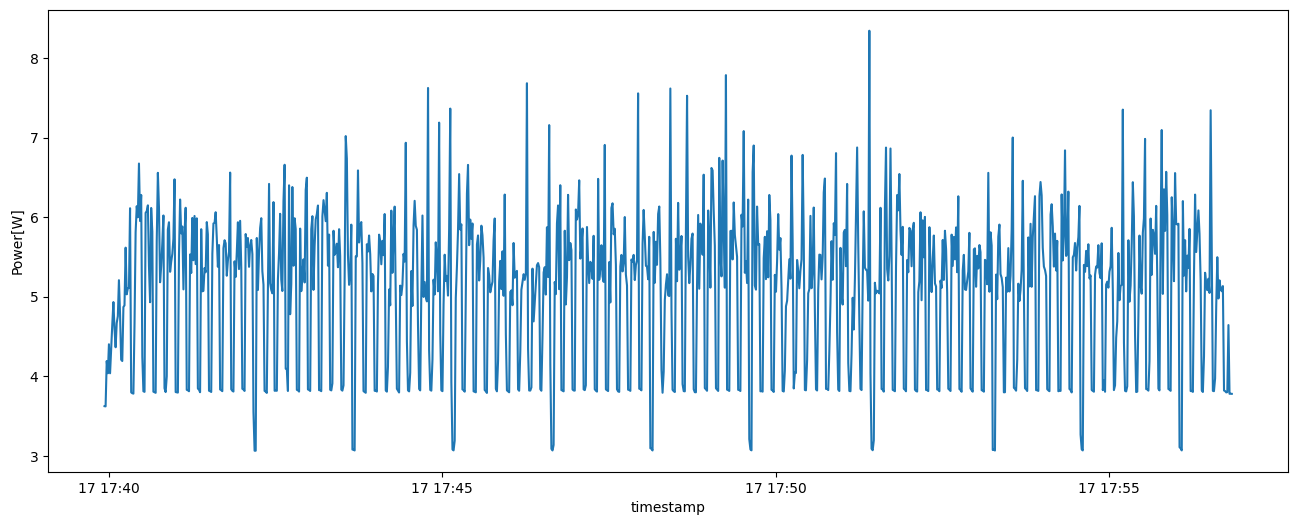

In [95]:
plt.figure(figsize=(16, 6))
sns.lineplot(data=dx23_power.sort_values(by='timestamp'), x="timestamp", y="Power[W]")
plt.show()

## X3.1 ~ Mas (Batch) | Baseline

passage_time: 10; interval: 3; window: 1; FPS: 1.0

In [169]:
x31_folder_path = '../infra/reports/mas-batch_500'

### Predict

In [189]:
from pandas import json_normalize
import json

with open(f'{x31_folder_path}/metrics.json') as f:
    x31_data = json.load(f)

load_model_duration = datetime.fromisoformat(x31_data['load_model_final']) - datetime.fromisoformat(x31_data['load_model_start'])
    
rows = []
for animal, v1 in x31_data['animals'].items():
    row = {
        'pid': x31_data['pid'],
        'load_model_start': datetime.fromisoformat(x31_data['load_model_start']),
        'load_model_final': datetime.fromisoformat(x31_data['load_model_final']),
        'load_model_dur': load_model_duration,
        'animal':animal,
        'first_image_capture_time':datetime.fromisoformat(v1['first_image_capture_time']),
        'last_image_capture_time' :datetime.fromisoformat(v1['last_image_capture_time']),
        'display_time' :datetime.fromisoformat(v1['weight_prediction_final']),
        'total_of_images':v1['total_of_images'],
        'suitable_images':v1['suitable_images'],       
    }
    
    for img, v2 in v1['imgs'].items():
        for k, v3 in v2.items():
            row[k] = datetime.fromisoformat(v3)

        rows.append(row)

dx31_metrics_v0 = pd.DataFrame.from_dict(rows)
dx31_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final
0,mas-batch_2026-05-27T08:23:48.704537,2026-05-27 08:23:50.203445,2026-05-27 08:24:01.189377,0 days 00:00:10.985932,1,2026-05-27 08:24:01.217762,2026-05-27 08:24:10.227133,2026-05-27 08:24:12.520665,10,3,2026-05-27 08:24:11.238532,2026-05-27 08:24:12.520549
1,mas-batch_2026-05-27T08:23:48.704537,2026-05-27 08:23:50.203445,2026-05-27 08:24:01.189377,0 days 00:00:10.985932,2,2026-05-27 08:24:14.232391,2026-05-27 08:24:23.238037,2026-05-27 08:24:25.543296,10,3,2026-05-27 08:24:24.244250,2026-05-27 08:24:25.543175
2,mas-batch_2026-05-27T08:23:48.704537,2026-05-27 08:23:50.203445,2026-05-27 08:24:01.189377,0 days 00:00:10.985932,3,2026-05-27 08:24:27.243090,2026-05-27 08:24:36.248238,2026-05-27 08:24:38.584944,10,3,2026-05-27 08:24:37.254768,2026-05-27 08:24:38.584836
3,mas-batch_2026-05-27T08:23:48.704537,2026-05-27 08:23:50.203445,2026-05-27 08:24:01.189377,0 days 00:00:10.985932,4,2026-05-27 08:24:40.253599,2026-05-27 08:24:49.258153,2026-05-27 08:24:51.566314,10,3,2026-05-27 08:24:50.264324,2026-05-27 08:24:51.566220
4,mas-batch_2026-05-27T08:23:48.704537,2026-05-27 08:23:50.203445,2026-05-27 08:24:01.189377,0 days 00:00:10.985932,5,2026-05-27 08:24:53.261195,2026-05-27 08:25:02.267152,2026-05-27 08:25:04.533355,10,3,2026-05-27 08:25:03.274071,2026-05-27 08:25:04.533262


In [171]:
dx31_metrics_v0['by_animal_lead_time'] = dx31_metrics_v0['display_time'] - dx31_metrics_v0['first_image_capture_time']
dx31_metrics_v0['by_animal_processing_delay'] = dx31_metrics_v0['weight_prediction_final'] - dx31_metrics_v0['weight_prediction_start']
dx31_metrics_v0['by_animal_latency'] = dx31_metrics_v0['display_time'] - dx31_metrics_v0['last_image_capture_time']

dx31_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final,by_animal_lead_time,by_animal_processing_delay,by_animal_latency
0,mas-batch_2026-05-27T08:23:48.704537,2026-05-27 08:23:50.203445,2026-05-27 08:24:01.189377,0 days 00:00:10.985932,1,2026-05-27 08:24:01.217762,2026-05-27 08:24:10.227133,2026-05-27 08:24:12.520665,10,3,2026-05-27 08:24:11.238532,2026-05-27 08:24:12.520549,0 days 00:00:11.302903,0 days 00:00:01.282017,0 days 00:00:02.293532
1,mas-batch_2026-05-27T08:23:48.704537,2026-05-27 08:23:50.203445,2026-05-27 08:24:01.189377,0 days 00:00:10.985932,2,2026-05-27 08:24:14.232391,2026-05-27 08:24:23.238037,2026-05-27 08:24:25.543296,10,3,2026-05-27 08:24:24.244250,2026-05-27 08:24:25.543175,0 days 00:00:11.310905,0 days 00:00:01.298925,0 days 00:00:02.305259
2,mas-batch_2026-05-27T08:23:48.704537,2026-05-27 08:23:50.203445,2026-05-27 08:24:01.189377,0 days 00:00:10.985932,3,2026-05-27 08:24:27.243090,2026-05-27 08:24:36.248238,2026-05-27 08:24:38.584944,10,3,2026-05-27 08:24:37.254768,2026-05-27 08:24:38.584836,0 days 00:00:11.341854,0 days 00:00:01.330068,0 days 00:00:02.336706
3,mas-batch_2026-05-27T08:23:48.704537,2026-05-27 08:23:50.203445,2026-05-27 08:24:01.189377,0 days 00:00:10.985932,4,2026-05-27 08:24:40.253599,2026-05-27 08:24:49.258153,2026-05-27 08:24:51.566314,10,3,2026-05-27 08:24:50.264324,2026-05-27 08:24:51.566220,0 days 00:00:11.312715,0 days 00:00:01.301896,0 days 00:00:02.308161
4,mas-batch_2026-05-27T08:23:48.704537,2026-05-27 08:23:50.203445,2026-05-27 08:24:01.189377,0 days 00:00:10.985932,5,2026-05-27 08:24:53.261195,2026-05-27 08:25:02.267152,2026-05-27 08:25:04.533355,10,3,2026-05-27 08:25:03.274071,2026-05-27 08:25:04.533262,0 days 00:00:11.272160,0 days 00:00:01.259191,0 days 00:00:02.266203


In [172]:
collect_lead_time = dx31_metrics_v0['display_time'].max() - dx31_metrics_v0['first_image_capture_time'].min()
qtt = len(dx31_metrics_v0['animal'].unique())

dx31_metrics_v0['collect_lead_time'] = collect_lead_time
dx31_metrics_v0['mean_throughput'] = qtt / (collect_lead_time.total_seconds() / 60 / 60) # hour

dx31_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final,by_animal_lead_time,by_animal_processing_delay,by_animal_latency,collect_lead_time,mean_throughput
0,mas-batch_2026-05-27T08:23:48.704537,2026-05-27 08:23:50.203445,2026-05-27 08:24:01.189377,0 days 00:00:10.985932,1,2026-05-27 08:24:01.217762,2026-05-27 08:24:10.227133,2026-05-27 08:24:12.520665,10,3,2026-05-27 08:24:11.238532,2026-05-27 08:24:12.520549,0 days 00:00:11.302903,0 days 00:00:01.282017,0 days 00:00:02.293532,0 days 01:48:25.985810,276.668295
1,mas-batch_2026-05-27T08:23:48.704537,2026-05-27 08:23:50.203445,2026-05-27 08:24:01.189377,0 days 00:00:10.985932,2,2026-05-27 08:24:14.232391,2026-05-27 08:24:23.238037,2026-05-27 08:24:25.543296,10,3,2026-05-27 08:24:24.244250,2026-05-27 08:24:25.543175,0 days 00:00:11.310905,0 days 00:00:01.298925,0 days 00:00:02.305259,0 days 01:48:25.985810,276.668295
2,mas-batch_2026-05-27T08:23:48.704537,2026-05-27 08:23:50.203445,2026-05-27 08:24:01.189377,0 days 00:00:10.985932,3,2026-05-27 08:24:27.243090,2026-05-27 08:24:36.248238,2026-05-27 08:24:38.584944,10,3,2026-05-27 08:24:37.254768,2026-05-27 08:24:38.584836,0 days 00:00:11.341854,0 days 00:00:01.330068,0 days 00:00:02.336706,0 days 01:48:25.985810,276.668295
3,mas-batch_2026-05-27T08:23:48.704537,2026-05-27 08:23:50.203445,2026-05-27 08:24:01.189377,0 days 00:00:10.985932,4,2026-05-27 08:24:40.253599,2026-05-27 08:24:49.258153,2026-05-27 08:24:51.566314,10,3,2026-05-27 08:24:50.264324,2026-05-27 08:24:51.566220,0 days 00:00:11.312715,0 days 00:00:01.301896,0 days 00:00:02.308161,0 days 01:48:25.985810,276.668295
4,mas-batch_2026-05-27T08:23:48.704537,2026-05-27 08:23:50.203445,2026-05-27 08:24:01.189377,0 days 00:00:10.985932,5,2026-05-27 08:24:53.261195,2026-05-27 08:25:02.267152,2026-05-27 08:25:04.533355,10,3,2026-05-27 08:25:03.274071,2026-05-27 08:25:04.533262,0 days 00:00:11.272160,0 days 00:00:01.259191,0 days 00:00:02.266203,0 days 01:48:25.985810,276.668295


In [173]:
dx31_metrics_v0[['total_of_images', 'suitable_images', 'by_animal_processing_delay', 'by_animal_latency', 'mean_throughput']].describe()

,total_of_images,suitable_images,by_animal_processing_delay,by_animal_latency,mean_throughput
count,500.0,500.0,500,500,500.000000
mean,10.0,3.0,0 days 00:00:01.274030,0 days 00:00:02.291673,276.668295
std,0.0,0.0,0 days 00:00:00.029943,0 days 00:00:00.032402,0.000000
min,10.0,3.0,0 days 00:00:01.237978,0 days 00:00:02.246596,276.668295
25%,10.0,3.0,0 days 00:00:01.252582,0 days 00:00:02.267434,276.668295
50%,10.0,3.0,0 days 00:00:01.261944,0 days 00:00:02.279717,276.668295
75%,10.0,3.0,0 days 00:00:01.297226,0 days 00:00:02.313842,276.668295
max,10.0,3.0,0 days 00:00:01.539781,0 days 00:00:02.548815,276.668295


In [174]:
total_processing_delay = dx31_metrics_v0['by_animal_processing_delay'].sum()
total_processing_delay

Timedelta('0 days 00:10:37.015039')

In [175]:
total_of_imgs = dx31_metrics_v0['total_of_images'].sum()
suitable_imgs = dx31_metrics_v0['suitable_images'].sum()

total_time = pd.to_timedelta(dx31_metrics_v0['collect_lead_time'].unique()[0])

print(f'{int(total_of_imgs)} images in {total_time} => {(total_of_imgs / total_time.total_seconds()):.2f} FPS;')
print(f'{int(suitable_imgs)} images in {total_processing_delay} => {(suitable_imgs / total_processing_delay.total_seconds()):.2f} FPS;')
print(f'{(total_processing_delay.total_seconds() / total_time.total_seconds() * 100):.2f}% with inference;')

5000 images in 0 days 01:48:25.985810 => 0.77 FPS;
1500 images in 0 days 00:10:37.015039 => 2.35 FPS;
9.79% with inference;


### CPU

In [176]:
dx31_cpu = pd.read_csv(f'{x31_folder_path}/cpu.csv')

dx31_cpu['timestamp'] = dx31_cpu['timestamp'].apply(lambda x: datetime.fromisoformat(x))
dx31_cpu['cpu_mean']  = dx31_cpu[['cpu_core_0', 'cpu_core_1', 'cpu_core_2', 'cpu_core_3']].mean(axis=1)

dx31_cpu.head()

,timestamp,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
0,2026-05-27 08:23:51.202695,49.5,5.1,17.2,56.7,32.125
1,2026-05-27 08:23:52.205387,18.4,32.0,53.5,30.0,33.475
2,2026-05-27 08:23:53.209119,44.6,30.3,42.2,51.5,42.150
3,2026-05-27 08:23:54.211663,54.5,35.9,28.0,7.9,31.575
4,2026-05-27 08:23:55.212921,68.9,72.4,0.0,0.0,35.325


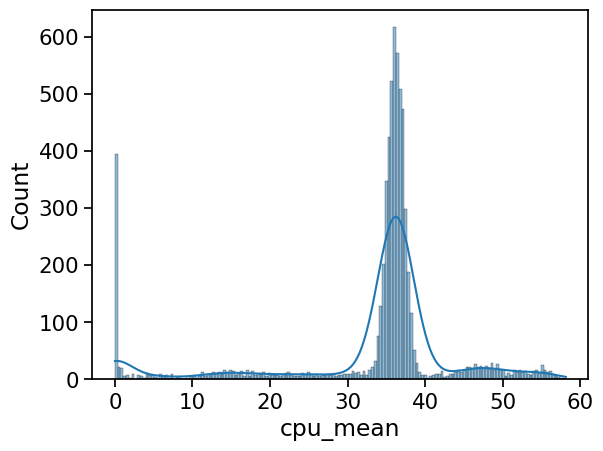

In [177]:
sns.histplot(data=dx31_cpu, x="cpu_mean", kde=True)
plt.show()

In [178]:
dx31_cpu.describe()

,timestamp,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
count,6497,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,2026-05-27 09:18:09.039236,31.614099,35.026920,35.028936,30.935247,33.151301
min,2026-05-27 08:23:51.202695,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2026-05-27 08:50:59.950868,20.400000,22.700000,22.500000,20.400000,34.800000
50%,2026-05-27 09:18:08.810099,31.300000,35.000000,35.100000,30.900000,36.075000
75%,2026-05-27 09:45:17.939499,42.900000,47.500000,47.400000,41.000000,37.150000
max,2026-05-27 10:12:27.244165,85.400000,88.900000,87.300000,86.100000,58.150000
std,NaN,16.671600,18.040202,17.895076,16.138681,11.917137


In [179]:
threshold = dx31_cpu['cpu_mean'].quantile(0.95)
dx31_cpu[dx31_cpu['cpu_mean'] > threshold].describe()

,timestamp,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
count,325,325.000000,325.000000,325.000000,325.000000,325.000000
mean,2026-05-27 09:18:11.370078,52.242769,53.132615,53.097538,52.760923,52.808462
min,2026-05-27 08:24:12.387175,35.400000,36.700000,35.600000,36.700000,48.775000
25%,2026-05-27 08:52:49.235355,46.900000,47.900000,47.900000,46.900000,50.375000
50%,2026-05-27 09:18:38.080550,52.100000,52.500000,52.400000,52.500000,52.775000
75%,2026-05-27 09:42:43.533277,57.400000,58.400000,57.600000,57.400000,55.050000
max,2026-05-27 10:11:35.095494,73.000000,71.400000,82.200000,76.300000,58.150000
std,NaN,7.515465,7.349073,7.508649,7.854816,2.514398


### RAM

In [180]:
dx31_ram = pd.read_csv(f'{x31_folder_path}/mem.csv')
dx31_ram['timestamp'] = dx31_ram['timestamp'].apply(lambda x: datetime.fromisoformat(x))
dx31_ram.head()

,timestamp,total,available,used,percent,free,active,inactive,buffers,cached
0,2026-05-27 08:23:50.201386,17002643456,16257646592,744996864,4.4,15608348672,788545536,227835904,44941312,724451328
1,2026-05-27 08:23:51.202831,17002643456,16237805568,764837888,4.5,15586000896,818020352,228622336,45056000,726712320
2,2026-05-27 08:23:52.205462,17002643456,16197320704,805322752,4.7,15545516032,864239616,228622336,45056000,726712320
3,2026-05-27 08:23:53.205836,17002643456,16099508224,903135232,5.3,15447703552,965001216,228622336,45056000,726712320
4,2026-05-27 08:23:54.206363,17002643456,16089137152,913506304,5.4,15437201408,957759488,228622336,45056000,726843392


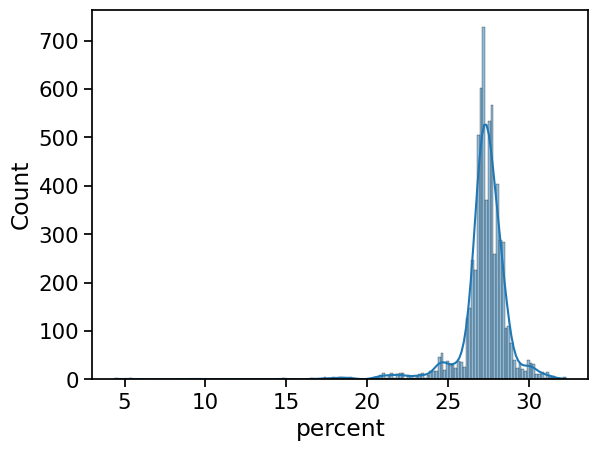

In [181]:
sns.histplot(data=dx31_ram, x="percent", kde=True)
plt.show()

In [182]:
dx31_ram.describe()

,timestamp,total,available,used,percent,free,active,inactive,buffers,cached
count,6503,6.503000e+03,6.503000e+03,6.503000e+03,6503.000000,6.503000e+03,6.503000e+03,6.503000e+03,6.503000e+03,6.503000e+03
mean,2026-05-27 09:18:08.930219,1.700264e+10,1.237887e+10,4.623775e+09,27.195156,1.150494e+10,4.830557e+09,3.882902e+08,4.583766e+07,9.483604e+08
min,2026-05-27 08:23:50.201386,1.700264e+10,1.150365e+10,7.449969e+08,4.400000,1.061426e+10,7.885455e+08,2.278359e+08,4.494131e+07,7.244513e+08
25%,2026-05-27 08:50:59.573414,1.700264e+10,1.225307e+10,4.567794e+09,26.900000,1.136617e+10,4.793893e+09,3.880223e+08,4.546560e+07,9.622159e+08
50%,2026-05-27 09:18:08.811277,1.700264e+10,1.235039e+10,4.652253e+09,27.400000,1.146569e+10,4.881351e+09,3.882680e+08,4.561306e+07,9.626911e+08
75%,2026-05-27 09:45:18.322054,1.700264e+10,1.243485e+10,4.749574e+09,27.900000,1.155649e+10,4.973552e+09,3.893658e+08,4.644864e+07,9.633300e+08
max,2026-05-27 10:12:27.679126,1.700264e+10,1.625765e+10,5.498995e+09,32.300000,1.560835e+10,5.567267e+09,3.897098e+08,4.654694e+07,9.636413e+08
std,NaN,0.000000e+00,3.095491e+08,3.095491e+08,1.820530,3.276653e+08,3.326511e+08,5.185680e+06,5.285416e+05,2.991934e+07


In [183]:
threshold = dx31_ram['percent'].quantile(0.95)
dx31_ram[dx31_ram['percent'] > threshold].describe()

,timestamp,total,available,used,percent,free,active,inactive,buffers,cached
count,313,3.130000e+02,3.130000e+02,3.130000e+02,313.000000,3.130000e+02,3.130000e+02,3.130000e+02,3.130000e+02,3.130000e+02
mean,2026-05-27 09:26:13.638007,1.700264e+10,1.189618e+10,5.106459e+09,30.035463,1.101483e+10,5.226409e+09,3.887061e+08,4.599580e+07,9.556731e+08
min,2026-05-27 08:34:37.718665,1.700264e+10,1.150365e+10,4.939694e+09,29.100000,1.061426e+10,4.917117e+09,3.873669e+08,4.526899e+07,8.895529e+08
25%,2026-05-27 09:03:15.773670,1.700264e+10,1.183135e+10,5.007524e+09,29.500000,1.094951e+10,5.129093e+09,3.880550e+08,4.549837e+07,9.622159e+08
50%,2026-05-27 09:34:03.211043,1.700264e+10,1.190774e+10,5.094900e+09,30.000000,1.101927e+10,5.225284e+09,3.893494e+08,4.643226e+07,9.633300e+08
75%,2026-05-27 09:49:00.292420,1.700264e+10,1.199512e+10,5.171298e+09,30.400000,1.112293e+10,5.318640e+09,3.893821e+08,4.646502e+07,9.633300e+08
max,2026-05-27 10:11:08.514251,1.700264e+10,1.206295e+10,5.498995e+09,32.300000,1.124821e+10,5.567267e+09,3.894641e+08,4.654694e+07,9.633464e+08
std,NaN,0.000000e+00,1.201212e+08,1.201212e+08,0.702414,1.261440e+08,1.350649e+08,7.352295e+05,4.981740e+05,2.195979e+07


### Power

In [184]:
dx31_power = pd.read_csv(f'{x31_folder_path}/power.csv')
dx31_power['timestamp'] = dx31_power['Datetime'].apply(lambda x: datetime.fromisoformat(x))
dx31_power.head()

,Datetime,Time[S],Volt[V],Current[A],Power[W],timestamp
0,2026-05-27T08:23:38.269918,0.0,5.1088,0.51568,2.6299,2026-05-27 08:23:38.269918
1,2026-05-27T08:23:39.285654,1.0,5.1084,0.67075,3.4208,2026-05-27 08:23:39.285654
2,2026-05-27T08:23:40.302193,2.0,5.1072,0.73697,3.7585,2026-05-27 08:23:40.302193
3,2026-05-27T08:23:41.274773,3.0,5.1084,0.72774,3.7114,2026-05-27 08:23:41.274773
4,2026-05-27T08:23:42.295394,4.0,5.1083,0.74078,3.7779,2026-05-27 08:23:42.295394


In [210]:
dx31_power = dx31_power.sort_values('timestamp')

# Time difference in hours
dx31_power['dt_hours'] = dx31_power['timestamp'].diff().dt.total_seconds() / 3600

# Energy (Wh)
dx31_power['energy_Wh'] = dx31_power['Power[W]'] * dx31_power['dt_hours']

# Total energy
total_energy_Wh = dx31_power['energy_Wh'].sum()

print("Total energy (Wh):", total_energy_Wh)

Total energy (Wh): 10.006884989032724


In [186]:
dx31_power.describe()

,Time[S],Volt[V],Current[A],Power[W],timestamp,dt_hours,energy_Wh
count,6533.000000,6533.000000,6533.000000,6533.000000,6533,6532.000000,6532.000000
mean,3266.665927,5.106827,1.080838,5.513705,2026-05-27 09:18:04.946736,0.000278,0.001532
min,0.000000,5.078700,0.515680,2.629900,2026-05-27 08:23:38.269918,0.000269,0.000837
25%,1633.300000,5.104700,1.026560,5.235300,2026-05-27 08:50:51.622800,0.000271,0.001450
50%,3266.700000,5.107300,1.092970,5.574400,2026-05-27 09:18:04.919973,0.000283,0.001548
75%,4900.000000,5.109500,1.167600,5.958700,2026-05-27 09:45:18.291189,0.000284,0.001659
max,6533.300000,5.129100,1.747540,8.912600,2026-05-27 10:12:31.633772,0.000286,0.002500
std,1886.445300,0.004809,0.163265,0.832884,NaN,0.000006,0.000234


## X4.0 ~ Mas (Single) | Baseline

passage_time: 10; interval: 3; window: 3

In [60]:
x40_folder_path = '../infra/reports/mas-single_500'

### Predict

In [61]:
from pandas import json_normalize
import json

with open(f'{x40_folder_path}/metrics.json') as f:
    x40_data = json.load(f)

load_model_duration = datetime.fromisoformat(x40_data['load_model_final']) - datetime.fromisoformat(x40_data['load_model_start'])
    
rows = []
for animal, v1 in x40_data['animals'].items():
    row_base = {
        'pid': x40_data['pid'],
        'load_model_start': datetime.fromisoformat(x40_data['load_model_start']),
        'load_model_final': datetime.fromisoformat(x40_data['load_model_final']),
        'load_model_dur': load_model_duration,
        'animal':animal,
        'first_image_capture_time':datetime.fromisoformat(v1['first_image_capture_time']),
        'last_image_capture_time' :datetime.fromisoformat(v1['last_image_capture_time']),
        'display_time' :datetime.fromisoformat(v1['weight_prediction_final']),
        'total_of_images': v1['total_of_images'],
        'suitable_images': v1['suitable_images'],
    }
    
    for img, v2 in v1['imgs'].items():
        row = row_base.copy()
        for k, v3 in v2.items():
            row[k] = datetime.fromisoformat(v3)

        rows.append(row)

dx40_metrics_v0 = pd.DataFrame.from_dict(rows)
dx40_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final
0,mas-single_2026-05-27T10:14:12.511857,2026-05-27 10:14:14.086535,2026-05-27 10:14:25.152254,0 days 00:00:11.065719,1,2026-05-27 10:14:26.102910,2026-05-27 10:14:35.126154,2026-05-27 10:14:37.969671,10,3,2026-05-27 10:14:27.568577,2026-05-27 10:14:30.104914
1,mas-single_2026-05-27T10:14:12.511857,2026-05-27 10:14:14.086535,2026-05-27 10:14:25.152254,0 days 00:00:11.065719,1,2026-05-27 10:14:26.102910,2026-05-27 10:14:35.126154,2026-05-27 10:14:37.969671,10,3,2026-05-27 10:14:29.679303,2026-05-27 10:14:34.116629
2,mas-single_2026-05-27T10:14:12.511857,2026-05-27 10:14:14.086535,2026-05-27 10:14:25.152254,0 days 00:00:11.065719,1,2026-05-27 10:14:26.102910,2026-05-27 10:14:35.126154,2026-05-27 10:14:37.969671,10,3,2026-05-27 10:14:31.528530,2026-05-27 10:14:36.867319
3,mas-single_2026-05-27T10:14:12.511857,2026-05-27 10:14:14.086535,2026-05-27 10:14:25.152254,0 days 00:00:11.065719,2,2026-05-27 10:14:39.131584,2026-05-27 10:14:48.149386,2026-05-27 10:14:50.745236,10,3,2026-05-27 10:14:40.294027,2026-05-27 10:14:42.405865
4,mas-single_2026-05-27T10:14:12.511857,2026-05-27 10:14:14.086535,2026-05-27 10:14:25.152254,0 days 00:00:11.065719,2,2026-05-27 10:14:39.131584,2026-05-27 10:14:48.149386,2026-05-27 10:14:50.745236,10,3,2026-05-27 10:14:42.448039,2026-05-27 10:14:46.118336


In [62]:
dx40_metrics_v0['img_weight_prediction_dur'] = dx40_metrics_v0['weight_prediction_final'] - dx40_metrics_v0['weight_prediction_start']
dx40_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final,img_weight_prediction_dur
0,mas-single_2026-05-27T10:14:12.511857,2026-05-27 10:14:14.086535,2026-05-27 10:14:25.152254,0 days 00:00:11.065719,1,2026-05-27 10:14:26.102910,2026-05-27 10:14:35.126154,2026-05-27 10:14:37.969671,10,3,2026-05-27 10:14:27.568577,2026-05-27 10:14:30.104914,0 days 00:00:02.536337
1,mas-single_2026-05-27T10:14:12.511857,2026-05-27 10:14:14.086535,2026-05-27 10:14:25.152254,0 days 00:00:11.065719,1,2026-05-27 10:14:26.102910,2026-05-27 10:14:35.126154,2026-05-27 10:14:37.969671,10,3,2026-05-27 10:14:29.679303,2026-05-27 10:14:34.116629,0 days 00:00:04.437326
2,mas-single_2026-05-27T10:14:12.511857,2026-05-27 10:14:14.086535,2026-05-27 10:14:25.152254,0 days 00:00:11.065719,1,2026-05-27 10:14:26.102910,2026-05-27 10:14:35.126154,2026-05-27 10:14:37.969671,10,3,2026-05-27 10:14:31.528530,2026-05-27 10:14:36.867319,0 days 00:00:05.338789
3,mas-single_2026-05-27T10:14:12.511857,2026-05-27 10:14:14.086535,2026-05-27 10:14:25.152254,0 days 00:00:11.065719,2,2026-05-27 10:14:39.131584,2026-05-27 10:14:48.149386,2026-05-27 10:14:50.745236,10,3,2026-05-27 10:14:40.294027,2026-05-27 10:14:42.405865,0 days 00:00:02.111838
4,mas-single_2026-05-27T10:14:12.511857,2026-05-27 10:14:14.086535,2026-05-27 10:14:25.152254,0 days 00:00:11.065719,2,2026-05-27 10:14:39.131584,2026-05-27 10:14:48.149386,2026-05-27 10:14:50.745236,10,3,2026-05-27 10:14:42.448039,2026-05-27 10:14:46.118336,0 days 00:00:03.670297


In [63]:
by_animal_dict = []

for animal, by_animal in dx40_metrics_v0.groupby('animal'):
    # .max() return the most recent date   
    by_animal_lead_time = by_animal['display_time'].max() - by_animal['first_image_capture_time'].iloc[0]
    by_animal_processing_delay = by_animal['img_weight_prediction_dur'].sum()
    by_animal_latency = by_animal['display_time'].max() - by_animal['last_image_capture_time'].max()
    
    by_animal_dict.append({
        'animal': animal,
        'by_animal_lead_time':by_animal_lead_time,
        'by_animal_processing_delay':by_animal_processing_delay,
        'by_animal_latency':by_animal_latency,
    })

dx40_metrics_v1 = dx40_metrics_v0.merge(
    pd.DataFrame.from_records(by_animal_dict),
    on='animal'
)
dx40_metrics_v1.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final,img_weight_prediction_dur,by_animal_lead_time,by_animal_processing_delay,by_animal_latency
0,mas-single_2026-05-27T10:14:12.511857,2026-05-27 10:14:14.086535,2026-05-27 10:14:25.152254,0 days 00:00:11.065719,1,2026-05-27 10:14:26.102910,2026-05-27 10:14:35.126154,2026-05-27 10:14:37.969671,10,3,2026-05-27 10:14:27.568577,2026-05-27 10:14:30.104914,0 days 00:00:02.536337,0 days 00:00:11.866761,0 days 00:00:12.312452,0 days 00:00:02.843517
1,mas-single_2026-05-27T10:14:12.511857,2026-05-27 10:14:14.086535,2026-05-27 10:14:25.152254,0 days 00:00:11.065719,1,2026-05-27 10:14:26.102910,2026-05-27 10:14:35.126154,2026-05-27 10:14:37.969671,10,3,2026-05-27 10:14:29.679303,2026-05-27 10:14:34.116629,0 days 00:00:04.437326,0 days 00:00:11.866761,0 days 00:00:12.312452,0 days 00:00:02.843517
2,mas-single_2026-05-27T10:14:12.511857,2026-05-27 10:14:14.086535,2026-05-27 10:14:25.152254,0 days 00:00:11.065719,1,2026-05-27 10:14:26.102910,2026-05-27 10:14:35.126154,2026-05-27 10:14:37.969671,10,3,2026-05-27 10:14:31.528530,2026-05-27 10:14:36.867319,0 days 00:00:05.338789,0 days 00:00:11.866761,0 days 00:00:12.312452,0 days 00:00:02.843517
3,mas-single_2026-05-27T10:14:12.511857,2026-05-27 10:14:14.086535,2026-05-27 10:14:25.152254,0 days 00:00:11.065719,2,2026-05-27 10:14:39.131584,2026-05-27 10:14:48.149386,2026-05-27 10:14:50.745236,10,3,2026-05-27 10:14:40.294027,2026-05-27 10:14:42.405865,0 days 00:00:02.111838,0 days 00:00:11.613652,0 days 00:00:10.573113,0 days 00:00:02.595850
4,mas-single_2026-05-27T10:14:12.511857,2026-05-27 10:14:14.086535,2026-05-27 10:14:25.152254,0 days 00:00:11.065719,2,2026-05-27 10:14:39.131584,2026-05-27 10:14:48.149386,2026-05-27 10:14:50.745236,10,3,2026-05-27 10:14:42.448039,2026-05-27 10:14:46.118336,0 days 00:00:03.670297,0 days 00:00:11.613652,0 days 00:00:10.573113,0 days 00:00:02.595850


In [64]:
collect_lead_time = dx40_metrics_v1['display_time'].max() - dx40_metrics_v1['first_image_capture_time'].min()
qtt = len(dx40_metrics_v1['animal'].unique())

dx40_metrics_v1['collect_lead_time'] = collect_lead_time
dx40_metrics_v1['mean_throughput'] = qtt / (collect_lead_time.total_seconds() / 60 / 60) # hour

dx40_metrics_v1.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final,img_weight_prediction_dur,by_animal_lead_time,by_animal_processing_delay,by_animal_latency,collect_lead_time,mean_throughput
0,mas-single_2026-05-27T10:14:12.511857,2026-05-27 10:14:14.086535,2026-05-27 10:14:25.152254,0 days 00:00:11.065719,1,2026-05-27 10:14:26.102910,2026-05-27 10:14:35.126154,2026-05-27 10:14:37.969671,10,3,2026-05-27 10:14:27.568577,2026-05-27 10:14:30.104914,0 days 00:00:02.536337,0 days 00:00:11.866761,0 days 00:00:12.312452,0 days 00:00:02.843517,0 days 01:48:32.976056,276.371352
1,mas-single_2026-05-27T10:14:12.511857,2026-05-27 10:14:14.086535,2026-05-27 10:14:25.152254,0 days 00:00:11.065719,1,2026-05-27 10:14:26.102910,2026-05-27 10:14:35.126154,2026-05-27 10:14:37.969671,10,3,2026-05-27 10:14:29.679303,2026-05-27 10:14:34.116629,0 days 00:00:04.437326,0 days 00:00:11.866761,0 days 00:00:12.312452,0 days 00:00:02.843517,0 days 01:48:32.976056,276.371352
2,mas-single_2026-05-27T10:14:12.511857,2026-05-27 10:14:14.086535,2026-05-27 10:14:25.152254,0 days 00:00:11.065719,1,2026-05-27 10:14:26.102910,2026-05-27 10:14:35.126154,2026-05-27 10:14:37.969671,10,3,2026-05-27 10:14:31.528530,2026-05-27 10:14:36.867319,0 days 00:00:05.338789,0 days 00:00:11.866761,0 days 00:00:12.312452,0 days 00:00:02.843517,0 days 01:48:32.976056,276.371352
3,mas-single_2026-05-27T10:14:12.511857,2026-05-27 10:14:14.086535,2026-05-27 10:14:25.152254,0 days 00:00:11.065719,2,2026-05-27 10:14:39.131584,2026-05-27 10:14:48.149386,2026-05-27 10:14:50.745236,10,3,2026-05-27 10:14:40.294027,2026-05-27 10:14:42.405865,0 days 00:00:02.111838,0 days 00:00:11.613652,0 days 00:00:10.573113,0 days 00:00:02.595850,0 days 01:48:32.976056,276.371352
4,mas-single_2026-05-27T10:14:12.511857,2026-05-27 10:14:14.086535,2026-05-27 10:14:25.152254,0 days 00:00:11.065719,2,2026-05-27 10:14:39.131584,2026-05-27 10:14:48.149386,2026-05-27 10:14:50.745236,10,3,2026-05-27 10:14:42.448039,2026-05-27 10:14:46.118336,0 days 00:00:03.670297,0 days 00:00:11.613652,0 days 00:00:10.573113,0 days 00:00:02.595850,0 days 01:48:32.976056,276.371352


In [207]:
dx40_metrics_v1[['total_of_images', 'suitable_images', 'by_animal_processing_delay', 'by_animal_latency', 'mean_throughput']].describe()

,total_of_images,suitable_images,by_animal_processing_delay,by_animal_latency,mean_throughput
count,1500.0,1500.0,1500,1500,1.500000e+03
mean,10.0,3.0,0 days 00:00:11.400671,0 days 00:00:02.718425,2.763714e+02
std,0.0,0.0,0 days 00:00:00.371438,0 days 00:00:00.116663,5.686238e-14
min,10.0,3.0,0 days 00:00:10.357256,0 days 00:00:02.484131,2.763714e+02
25%,10.0,3.0,0 days 00:00:11.196435,0 days 00:00:02.631779,2.763714e+02
50%,10.0,3.0,0 days 00:00:11.389019,0 days 00:00:02.709669,2.763714e+02
75%,10.0,3.0,0 days 00:00:11.565355,0 days 00:00:02.784194,2.763714e+02
max,10.0,3.0,0 days 00:00:14.195482,0 days 00:00:03.310099,2.763714e+02


In [140]:
total_processing_delay = dx40_metrics_v1.groupby('animal')['by_animal_processing_delay'].mean().reset_index(name='time')['time'].sum()
total_processing_delay

Timedelta('0 days 01:35:00.335678')

In [141]:
total_of_imgs = dx40_metrics_v1.groupby('animal')['total_of_images'].mean().reset_index(name='qtd')['qtd'].sum()
suitable_imgs = dx40_metrics_v1.groupby('animal')['suitable_images'].mean().reset_index(name='qtd')['qtd'].sum()

total_time = pd.to_timedelta(dx40_metrics_v1['collect_lead_time'].unique()[0])

print(f'{int(total_of_imgs)} images in {total_time} => {(total_of_imgs / total_time.total_seconds()):.2f} FPS;')
print(f'{int(suitable_imgs)} images in {total_processing_delay} => {(suitable_imgs / total_processing_delay.total_seconds()):.2f} FPS;')
print(f'{(total_processing_delay.total_seconds() / total_time.total_seconds() * 100):.2f}% with inference;')

5000 images in 0 days 01:48:32.976056 => 0.77 FPS;
1500 images in 0 days 01:35:00.335678 => 0.26 FPS;
87.52% with inference;


### CPU

In [68]:
dx40_cpu = pd.read_csv(f'{x40_folder_path}/cpu.csv')

dx40_cpu['timestamp'] = dx40_cpu['timestamp'].apply(lambda x: datetime.fromisoformat(x))
dx40_cpu['cpu_mean']  = dx40_cpu[['cpu_core_0', 'cpu_core_1', 'cpu_core_2', 'cpu_core_3']].mean(axis=1)

dx40_cpu.head()

,timestamp,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
0,2026-05-27 10:14:15.093908,26.7,25.5,18.8,57.8,32.200
1,2026-05-27 10:14:16.097455,64.7,25.5,37.1,9.0,34.075
2,2026-05-27 10:14:17.102661,47.0,39.2,37.4,43.6,41.800
3,2026-05-27 10:14:18.104766,58.4,4.0,6.0,57.0,31.350
4,2026-05-27 10:14:19.106401,67.0,0.0,0.0,73.8,35.200


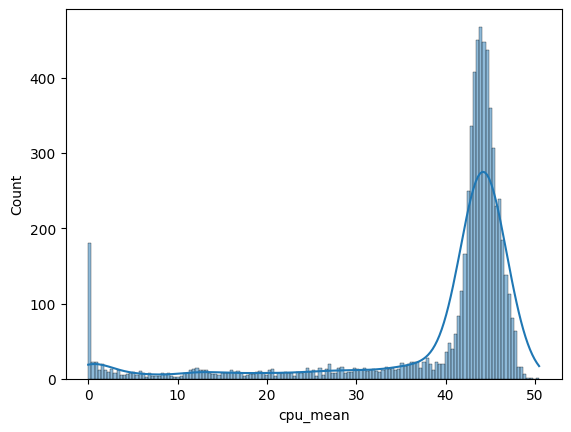

In [69]:
sns.histplot(data=dx40_cpu, x="cpu_mean", kde=True)
plt.show()

In [70]:
dx40_cpu.describe()

,timestamp,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
count,6452,6452.000000,6452.000000,6452.000000,6452.000000,6452.000000
mean,2026-05-27 11:08:37.492728,38.920242,39.407750,39.599117,38.694529,39.155409
min,2026-05-27 10:14:15.093908,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2026-05-27 10:41:26.093472,37.600000,38.500000,38.800000,37.800000,41.643750
50%,2026-05-27 11:08:37.220222,41.600000,42.600000,42.650000,42.100000,43.675000
75%,2026-05-27 11:35:48.735673,45.600000,46.100000,46.500000,45.600000,44.950000
max,2026-05-27 12:03:00.037761,83.300000,81.400000,85.700000,78.000000,50.475000
std,NaN,13.413232,13.629854,13.597658,13.365752,11.871734


In [71]:
threshold = dx40_cpu['cpu_mean'].quantile(0.95)
dx40_cpu[dx40_cpu['cpu_mean'] > threshold].describe()

,timestamp,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
count,317,317.000000,317.000000,317.000000,317.000000,317.000000
mean,2026-05-27 11:04:40.616163,47.384543,47.621767,47.994953,47.016404,47.504416
min,2026-05-27 10:14:30.314858,40.000000,39.800000,39.200000,39.800000,46.900000
25%,2026-05-27 10:35:07.380440,43.900000,44.300000,44.600000,44.100000,47.100000
50%,2026-05-27 11:03:49.237510,45.500000,46.200000,46.500000,45.600000,47.425000
75%,2026-05-27 11:32:29.401996,50.500000,48.500000,50.500000,48.100000,47.750000
max,2026-05-27 12:02:50.903538,59.400000,60.700000,59.800000,61.400000,50.475000
std,NaN,5.022744,4.677613,4.781588,4.501868,0.515124


### RAM

In [72]:
dx40_ram = pd.read_csv(f'{x40_folder_path}/mem.csv')
dx40_ram['timestamp'] = dx40_ram['timestamp'].apply(lambda x: datetime.fromisoformat(x))
dx40_ram.head()

,timestamp,total,available,used,percent,free,active,inactive,buffers,cached
0,2026-05-27 10:14:14.084490,17002643456,16328622080,674021376,4.0,15716745216,771342336,208420864,42598400,688652288
1,2026-05-27 10:14:15.092372,17002643456,16299786240,702857216,4.1,15684943872,801603584,209666048,42713088,691191808
2,2026-05-27 10:14:16.096618,17002643456,16248668160,753975296,4.4,15633825792,840712192,209666048,42713088,691191808
3,2026-05-27 10:14:17.101182,17002643456,16162897920,839745536,4.9,15548055552,945995776,209666048,42713088,691191808
4,2026-05-27 10:14:18.101935,17002643456,16139436032,863207424,5.1,15524462592,939917312,209666048,42713088,691322880


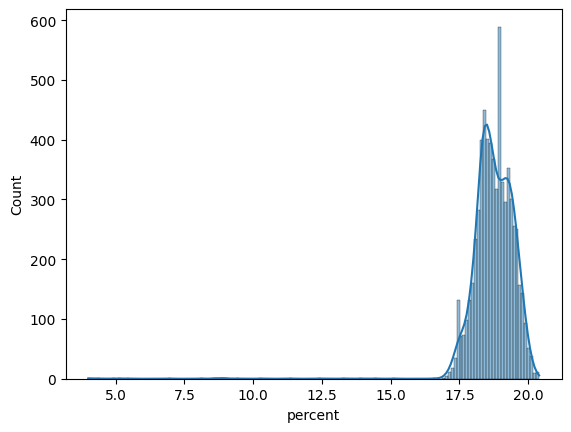

In [73]:
sns.histplot(data=dx40_ram, x="percent", kde=True)
plt.show()

In [74]:
dx40_ram.describe()

,timestamp,total,available,used,percent,free,active,inactive,buffers,cached
count,6477,6.477000e+03,6.477000e+03,6.477000e+03,6477.000000,6.477000e+03,6.477000e+03,6.477000e+03,6.477000e+03,6.477000e+03
mean,2026-05-27 11:08:36.730773,1.700264e+10,1.381649e+10,3.186158e+09,18.739802,1.303491e+10,3.336656e+09,3.704328e+08,4.438678e+07,8.580876e+08
min,2026-05-27 10:14:14.084490,1.700264e+10,1.353445e+10,6.740214e+08,4.000000,1.274400e+10,7.713423e+08,2.084209e+08,4.259840e+07,6.886523e+08
25%,2026-05-27 10:41:25.340281,1.700264e+10,1.372704e+10,3.117875e+09,18.300000,1.294500e+10,3.267903e+09,3.685745e+08,4.313907e+07,8.539013e+08
50%,2026-05-27 11:08:36.448440,1.700264e+10,1.381699e+10,3.185656e+09,18.700000,1.303406e+10,3.337912e+09,3.686728e+08,4.323738e+07,8.539341e+08
75%,2026-05-27 11:35:47.947117,1.700264e+10,1.388477e+10,3.275604e+09,19.300000,1.310310e+10,3.428303e+09,3.750461e+08,4.710400e+07,8.678769e+08
max,2026-05-27 12:03:00.086974,1.700264e+10,1.632862e+10,3.468198e+09,20.400000,1.571675e+10,3.621454e+09,3.756360e+08,4.721869e+07,8.683684e+08
std,NaN,0.000000e+00,1.458554e+08,1.458554e+08,0.858641,1.503408e+08,1.493921e+08,6.008610e+06,1.875133e+06,8.433890e+06


In [75]:
threshold = dx40_ram['percent'].quantile(0.95)
dx40_ram[dx40_ram['percent'] > threshold].describe()

,timestamp,total,available,used,percent,free,active,inactive,buffers,cached
count,202,2.020000e+02,2.020000e+02,2.020000e+02,202.000000,2.020000e+02,2.020000e+02,2.020000e+02,2.020000e+02,2.020000e+02
mean,2026-05-27 11:35:57.196604,1.700264e+10,1.360359e+10,3.399049e+09,19.998515,1.281701e+10,3.527412e+09,3.731070e+08,4.594666e+07,8.635292e+08
min,2026-05-27 10:38:12.984576,1.700264e+10,1.353445e+10,3.375268e+09,19.900000,1.274400e+10,3.434529e+09,3.685581e+08,4.312269e+07,8.539013e+08
25%,2026-05-27 11:22:11.767148,1.700264e+10,1.359132e+10,3.382260e+09,19.900000,1.280300e+10,3.504513e+09,3.687383e+08,4.330291e+07,8.539668e+08
50%,2026-05-27 11:43:13.217168,1.700264e+10,1.360892e+10,3.393724e+09,20.000000,1.282225e+10,3.529441e+09,3.751117e+08,4.716954e+07,8.678769e+08
75%,2026-05-27 11:55:24.255402,1.700264e+10,1.362038e+10,3.411325e+09,20.100000,1.283301e+10,3.551883e+09,3.751444e+08,4.720230e+07,8.678769e+08
max,2026-05-27 12:02:47.998299,1.700264e+10,1.362738e+10,3.468198e+09,20.400000,1.284941e+10,3.621454e+09,3.751608e+08,4.721869e+07,8.678932e+08
std,NaN,0.000000e+00,2.045404e+07,2.045404e+07,0.116533,2.220962e+07,3.563093e+07,2.987947e+06,1.824018e+06,6.471731e+06


### Power

In [76]:
dx40_power = pd.read_csv(f'{x40_folder_path}/power.csv')
dx40_power['timestamp'] = dx40_power['Datetime'].apply(lambda x: datetime.fromisoformat(x))
dx40_power.head()

,Datetime,Time[S],Volt[V],Current[A],Power[W],timestamp
0,2026-05-27T10:14:01.756320,0.0,5.1094,0.64110,3.2696,2026-05-27 10:14:01.756320
1,2026-05-27T10:14:02.773484,1.0,5.1096,0.73383,3.7425,2026-05-27 10:14:02.773484
2,2026-05-27T10:14:03.747567,2.0,5.1100,0.83808,4.2825,2026-05-27 10:14:03.747567
3,2026-05-27T10:14:04.767679,3.0,5.1094,0.80616,4.1114,2026-05-27 10:14:04.767679
4,2026-05-27T10:14:05.742848,4.0,5.1066,0.83271,4.2468,2026-05-27 10:14:05.742848


In [211]:
dx40_power = dx40_power.sort_values('timestamp')

# Time difference in hours
dx40_power['dt_hours'] = dx40_power['timestamp'].diff().dt.total_seconds() / 3600

# Energy (Wh)
dx40_power['energy_Wh'] = dx40_power['Power[W]'] * dx40_power['dt_hours']

# Total energy
total_energy_Wh = dx40_power['energy_Wh'].sum()

print("Total energy (Wh):", total_energy_Wh)

Total energy (Wh): 10.559782220414139


In [78]:
dx40_power.describe()

,Time[S],Volt[V],Current[A],Power[W],timestamp,dt_hours,energy_Wh
count,6543.000000,6543.000000,6543.000000,6543.000000,6543,6542.000000,6542.000000
mean,3271.690326,5.107474,1.138602,5.809250,2026-05-27 11:08:33.446905,0.000278,0.001614
min,0.000000,5.071700,0.620200,3.169200,2026-05-27 10:14:01.756320,0.000269,0.000862
25%,1635.800000,5.104700,1.071430,5.465150,2026-05-27 10:41:17.593404,0.000271,0.001516
50%,3271.700000,5.108100,1.150020,5.868300,2026-05-27 11:08:33.450850,0.000283,0.001629
75%,4907.500000,5.110800,1.232340,6.285700,2026-05-27 11:35:49.293284,0.000284,0.001749
max,6543.400000,5.131400,1.728100,8.796000,2026-05-27 12:03:05.107912,0.000286,0.002487
std,1889.343825,0.005725,0.161382,0.822594,NaN,0.000006,0.000232


# Charts

In [212]:
sns.set_context("notebook", font_scale=1.4)
window_size = 30

## CPU

In [213]:
dx10_cpu_w = dx10_cpu[['cpu_mean']].rolling(
    window=window_size, 
    center=True, 
    step=window_size
).max().dropna()

dx10_cpu_w['arch-str'] = 'SEQ-S'
dx10_cpu_w.shape

(230, 2)

In [214]:
dx20_cpu_w = dx20_cpu[['cpu_mean']].rolling(
    window=window_size, 
    center=True, 
    step=window_size
).max().dropna()

dx20_cpu_w['arch-str'] = 'SEQ-B'
dx20_cpu_w.shape

(242, 2)

In [215]:
dx30_cpu_w = dx31_cpu[['cpu_mean']].rolling(
    window=window_size, 
    center=True, 
    step=window_size
).max().dropna()

dx30_cpu_w['arch-str'] = 'MAS-B'
dx30_cpu_w.shape

(216, 2)

In [216]:
dx40_cpu_w = dx40_cpu[['cpu_mean']].rolling(
    window=window_size, 
    center=True, 
    step=window_size
).max().dropna()

dx40_cpu_w['arch-str'] = 'MAS-S'
dx40_cpu_w.shape

(214, 2)

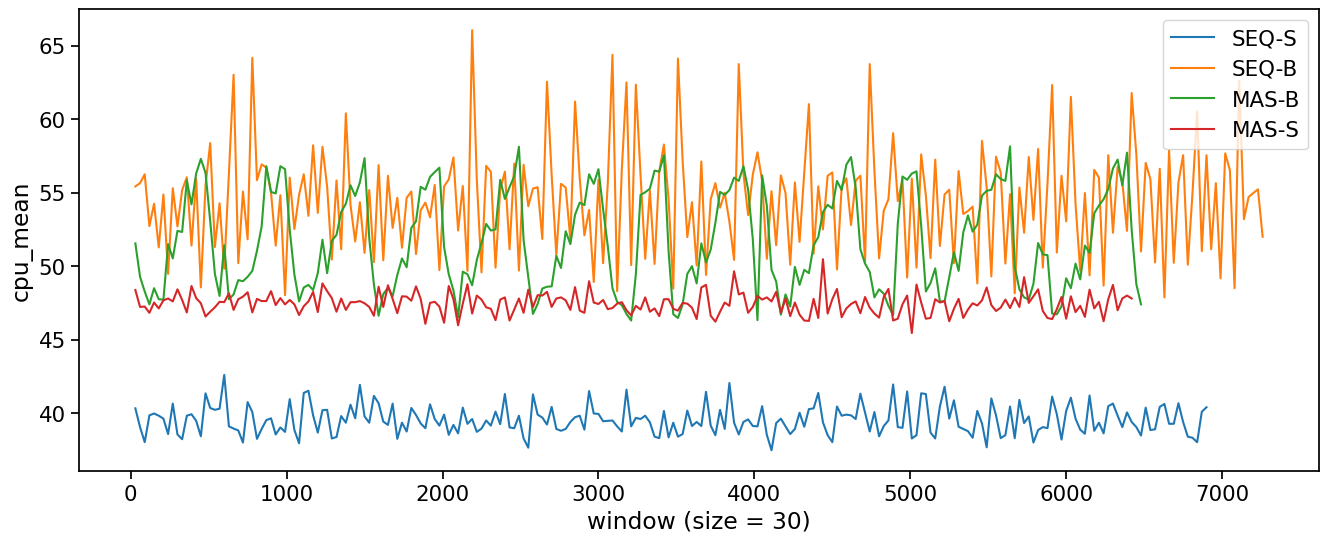

In [217]:
dall_cpu = pd.concat([dx10_cpu_w, dx20_cpu_w, dx30_cpu_w, dx40_cpu_w])
dall_cpu.sort_index().head()

plt.figure(figsize=(16, 6))

ax = sns.lineplot(data=dall_cpu, x=dall_cpu.index, y="cpu_mean", hue='arch-str', )
ax.legend().set_title('')
ax.set_xlabel(f'window (size = {window_size})')

# Save with 600 DPI
plt.savefig("output/cpu-mean-chart.pdf", format="pdf", dpi=600, bbox_inches="tight")

## RAM

In [218]:
dx10_ram_w = dx10_ram[['percent']].rolling(
    window=window_size, 
    center=True, 
    step=window_size
).max().dropna()

dx10_ram_w['arch-str'] = 'SEQ-S'
dx10_ram_w.shape

(231, 2)

In [219]:
dx20_ram_w = dx20_ram[['percent']].rolling(
    window=window_size, 
    center=True, 
    step=window_size
).max().dropna()

dx20_ram_w['arch-str'] = 'SEQ-B'
dx20_ram_w.shape

(242, 2)

In [220]:
dx30_ram_w = dx31_ram[['percent']].rolling(
    window=window_size, 
    center=True, 
    step=window_size
).max().dropna()

dx30_ram_w['arch-str'] = 'MAS-B'
dx30_ram_w.shape

(216, 2)

In [221]:
dx40_ram_w = dx40_ram[['percent']].rolling(
    window=window_size, 
    center=True, 
    step=window_size
).max().dropna()

dx40_ram_w['arch-str'] = 'MAS-S'
dx40_ram_w.shape

(215, 2)

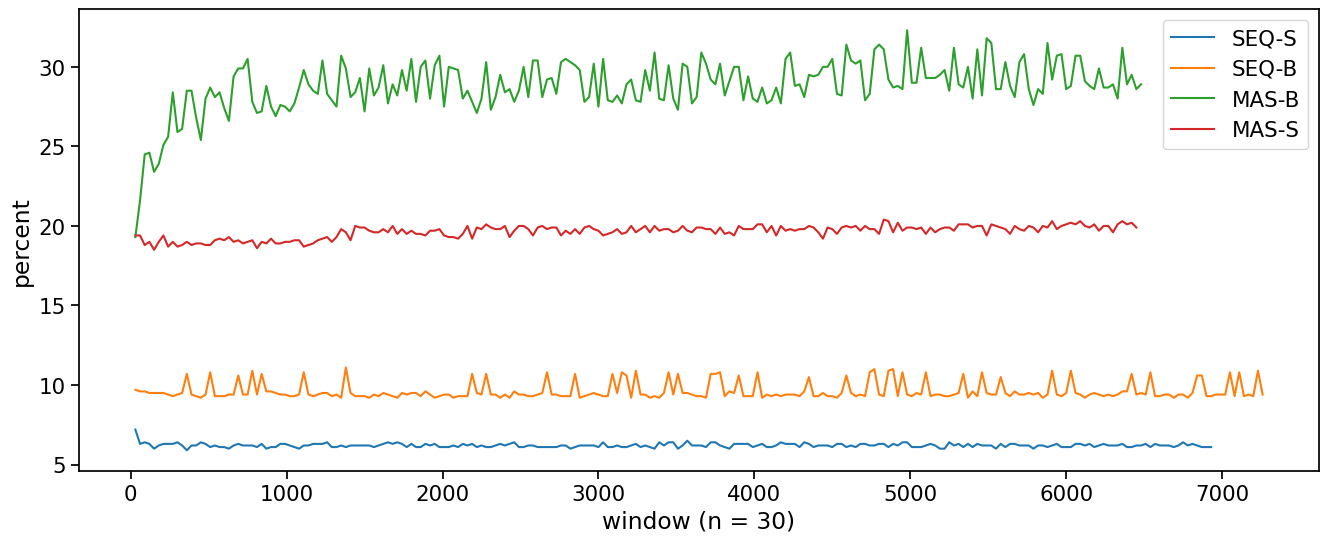

In [222]:
dall_ram = pd.concat([dx10_ram_w, dx20_ram_w, dx30_ram_w, dx40_ram_w])
dall_ram.sort_index().head()

plt.figure(figsize=(16, 6))

ax = sns.lineplot(data=dall_ram, x=dall_ram.index, y="percent", hue='arch-str')
ax.legend().set_title('')
ax.set_xlabel(f'window (n = {window_size})')

# Save with 600 DPI
plt.savefig("output/ram-mean-chart.pdf", format="pdf", dpi=600, bbox_inches="tight")

## POWER

In [239]:
dx10_power_w = dx10_power[['Power[W]']].rolling(
    window=window_size, 
    center=True, 
    step=window_size
).max().dropna()

dx10_power_w['variant'] = 'SEQ-S'
dx10_power_w.shape

(232, 2)

In [240]:
dx20_power_w = dx20_power[['Power[W]']].rolling(
    window=window_size, 
    center=True, 
    step=window_size
).max().dropna()

dx20_power_w['variant'] = 'SEQ-B'
dx20_power_w.shape

(243, 2)

In [241]:
dx30_power_w = dx31_power[['Power[W]']].rolling(
    window=window_size, 
    center=True, 
    step=window_size
).max().dropna()

dx30_power_w['variant'] = 'MAS-B'
dx30_power_w.shape

(217, 2)

In [242]:
dx40_power_w = dx40_power[['Power[W]']].rolling(
    window=window_size, 
    center=True, 
    step=window_size
).max().dropna()

dx40_power_w['variant'] = 'MAS-S'
dx40_power_w.shape

(217, 2)

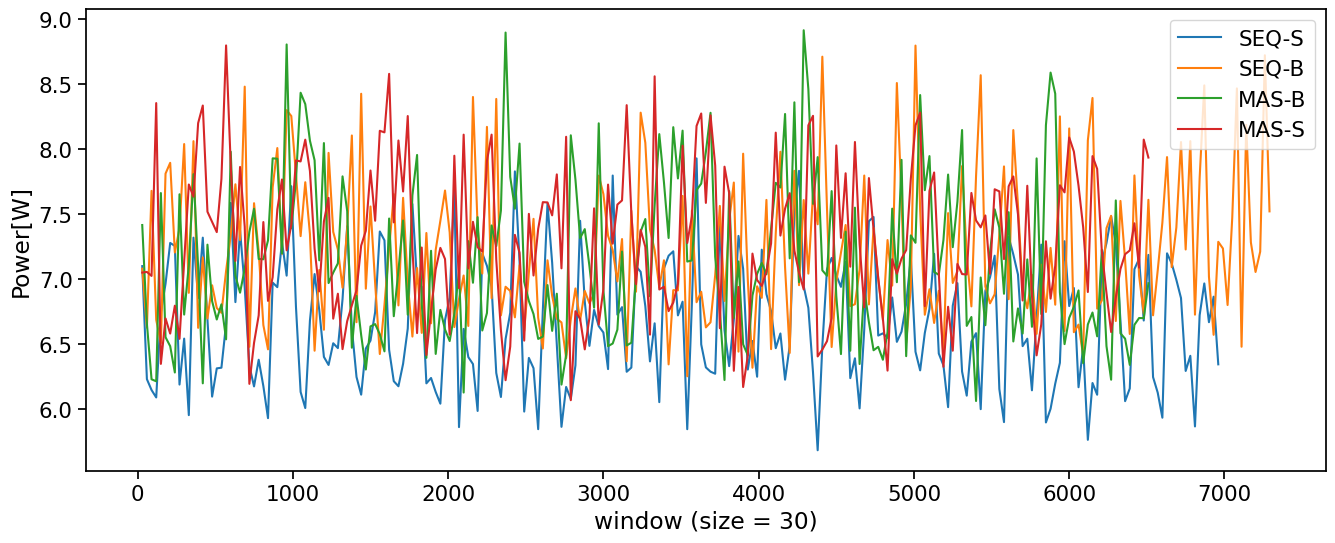

In [243]:
dall_power = pd.concat([dx10_power_w, dx20_power_w, dx30_power_w, dx40_power_w])
dall_power.sort_index().head()

plt.figure(figsize=(16, 6))

ax = sns.lineplot(data=dall_power, x=dall_power.index, y="Power[W]", hue='variant')
ax.legend().set_title('')
ax.set_xlabel(f'window (size = {window_size})')

# Save with 600 DPI
plt.savefig("output/power-mean-chart.pdf", format="pdf", dpi=600, bbox_inches="tight")

<Figure size 1600x600 with 0 Axes>

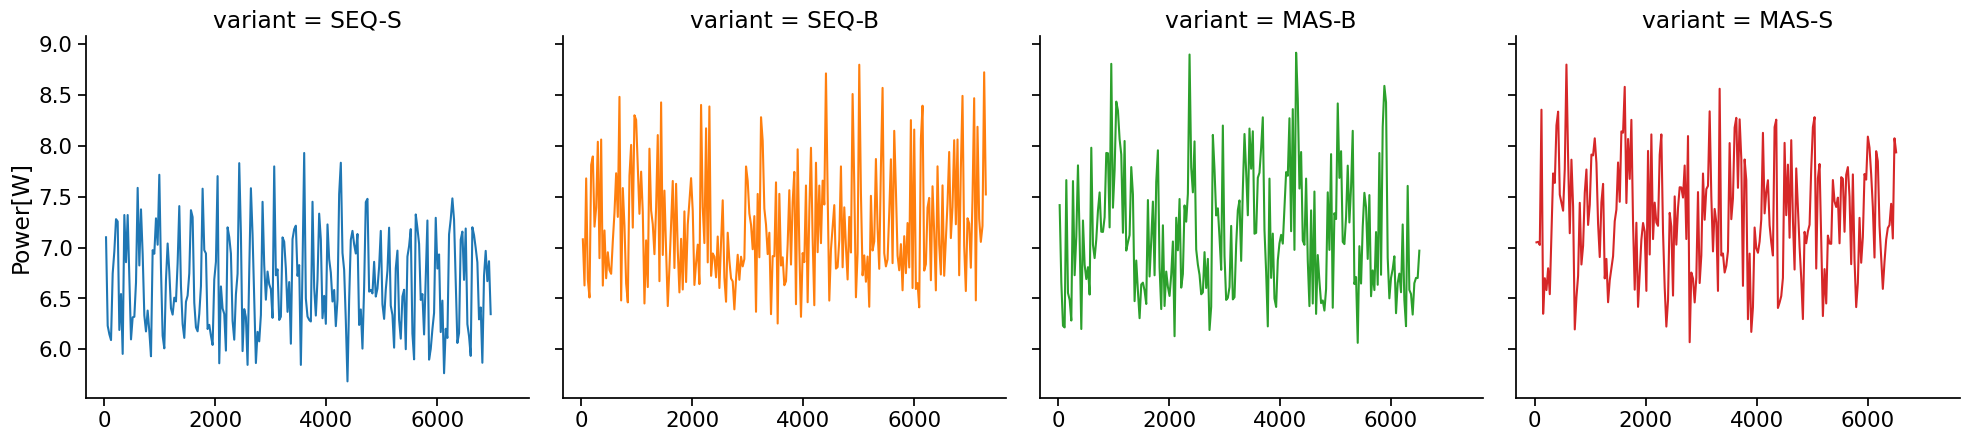

In [246]:
dall_power = pd.concat([dx10_power_w, dx20_power_w, dx30_power_w, dx40_power_w])
dall_power.sort_index().head()

plt.figure(figsize=(16, 6))

g = sns.relplot(kind='line', data=dall_power, x=dall_power.index, y="Power[W]", col="variant", hue='variant', legend=False)
for ax in g.axes.flat:
    ax.set_xlabel("")
    
# ax.legend().set_title('')
# ax.set_xlabel(f'window (size = {window_size})')

# Save with 600 DPI
plt.savefig("output/power-mean-chart.pdf", format="pdf", dpi=600, bbox_inches="tight")